# EXPERIMENT: EXP-VIT-SCRATCH-5SEEDS-005 — FINAL TEST CONTINUATION

## Vision Transformer (ViT) Scratch — 5-Seed Robustness Baseline

Notebook này dùng **cùng protocol khoa học và cùng format archive** như ResNet50 và DenseNet121:

- Dataset cố định: `Cashew_dataV05`
- Cùng Train / Validation / Test split cho mọi seed
- 5 seeds: `[42, 123, 2026, 3407, 7777]`
- Không đổi hyperparameters giữa các seed
- Checkpoint chọn theo **minimum validation loss**
- Test Set mặc định bị khóa
- Không chọn seed tốt nhất dựa trên Test
- Báo cáo `Mean ± sample Standard Deviation (ddof=1)`
- Figure so sánh 5 seed phải **đặt cạnh nhau trong cùng một panel**

## ViT baseline

```text
Input                 : 224 × 224 × 3
Patch size            : 16 × 16
Patch tokens          : 196
Projection dimension  : 64
Transformer blocks    : 8
Attention heads       : 4
Transformer MLP       : 128
Attention dropout     : 0.10
Transformer dropout   : 0.10
Classifier head       : Dense(256, GELU) + Dropout(0.40)
Optimizer             : AdamW
Initial LR            : 3e-4
Weight decay          : 1e-4
Batch size            : 32
Max epochs            : 60
```

Đây là **ViT train from scratch**, không dùng pretrained weights.

## Dataset

| Class | Train | Val | Test | Total |
|---|---:|---:|---:|---:|
| anthracnose | 945 | 294 | 122 | 1361 |
| healthy | 806 | 225 | 118 | 1149 |
| leaf_miner | 893 | 249 | 132 | 1274 |
| not_cashew_leaf | 1101 | 314 | 157 | 1572 |
| red_rust | 1077 | 320 | 158 | 1555 |
| **TOTAL** | **4822** | **1402** | **687** | **6911** |

## Figure format

```text
figures/panels/
├── training_curves_5seeds_panel.png
├── validation_confusion_matrices_5seeds_panel.png
├── test_confusion_matrices_5seeds_panel.png
└── test_confusion_matrices_normalized_5seeds_panel.png
```

`training_curves_5seeds_panel.png` dùng bố cục **2 hàng × 5 cột**:
- hàng 1: Accuracy
- hàng 2: Loss
- mỗi cột: một seed

## Archive dùng lại cho YOLO

FULL ZIP lưu cả 5 best checkpoints và:

```text
model_package/
├── deployment_model.keras
├── vit_token_feature_extractor.keras
├── vit_embedding_model.keras
├── deployment_metadata.json
└── label_map.json
```

Deployment seed được chọn bằng **Validation Macro-F1**, không dùng Test.

Google Drive archive target:

```text
https://drive.google.com/drive/folders/1it9ayE473c0lLgxhiNnguqIkKtceI5zf?usp=sharing
```

Colab qua VS Code: đọc `MyDrive/Cashew_Leaf_model_result/Dataset/CashewData_Split (5).zip`, giải nén vào `/content`, lưu kết quả trực tiếp trong `MyDrive/Cashew_Leaf_model_result/training_results/current_dataset`. Chỉnh DRIVE_DATASET_DIR hoặc DRIVE_PROJECT_DIR nếu thư mục nằm nơi khác.

Lần chạy này giữ nguyên EXPERIMENT_ID 005, đặt RUN_TRAINING=False và RUN_FINAL_TEST=True để đọc checkpoint đã lưu rồi chạy Test khóa.
## Thời gian huấn luyện và hình ma trận

Thời gian được đo quanh `model.fit`, gồm Validation mỗi epoch và callback/checkpoint; lưu trong `training_time_seconds` của từng seed và `aggregate/training_summary_5seeds.csv`.
Ma trận dùng thang trắng–xanh nhạt và chữ đen. Chọn experiment ID mới khi huấn luyện lại; dùng `RUN_TRAINING=False` để đọc và vẽ lại kết quả đã lưu.


## Resume experiment 005 for the locked Final Test

This notebook resumes the existing five EXP-005 Validation checkpoints. It does not
train a new experiment: `RUN_TRAINING=False`, `RUN_FINAL_TEST=True`.

This continuation evaluates only the original **V05 Test (687 images)**.
`RUN_REAL_HOLDOUT=False`, so the separate external holdout is not evaluated.

The external archive has four supported classes (13 anthracnose, 5 healthy,
24 leaf_miner, 7 red_rust), with **no not_cashew_leaf ground truth**. Keep five output
classes; holdout headline macro metrics use only the four supported true classes.
An absent true class is reported as N/A, not as proven zero performance. Raw counts
and normalized matrices retain all five model labels, with white/light-blue cells
and black text.

External results are in `real_holdout/`, not mixed into `test_*` results. Checkpoint
hashes and the validation-only deployment seed are frozen before external prediction.
The archive is pinned by SHA-256 and audited for exact-byte overlap with V05.
Near-duplicates/shared leaf or capture-session groups still need a separate audit.


In [1]:

# ============================================================
# 01. IMPORT LIBRARIES
# ============================================================

import os
import sys
import io
import gc
import json
import time
import random
import shutil
import platform
import zipfile
import hashlib
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from PIL import Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    ConfusionMatrixDisplay,
)

from IPython.display import display
import ipywidgets as widgets

MATRIX_CMAP = LinearSegmentedColormap.from_list(
    "readable_blues", ["#ffffff", "#dbeafe", "#93c5fd"]
)

print("Imports completed.")


Imports completed.


In [2]:

# ============================================================
# 02. ENVIRONMENT INFORMATION
# ============================================================

print(f"Date              : {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Python            : {sys.version.split()[0]}")
print(f"TensorFlow        : {tf.__version__}")
print(f"Keras             : {keras.__version__ if hasattr(keras, '__version__') else 'tf.keras'}")
RUNTIME = ("Windows" if os.name == "nt" else "Kaggle" if Path("/kaggle/working").is_dir() else "Colab" if Path("/content").is_dir() else platform.system())
print(f"Runtime           : {RUNTIME}")
print(f"OS                : {platform.platform()}")

gpus = tf.config.list_physical_devices("GPU")
print(f"GPU Count         : {len(gpus)}")
if RUNTIME == "Colab" and not gpus:
    raise RuntimeError("Colab has no GPU. Select a GPU runtime and rerun from the first cell.")

for i, gpu in enumerate(gpus):
    print(f"GPU {i}             : {gpu}")

if len(gpus) >= 2:
    strategy = tf.distribute.MirroredStrategy()
elif len(gpus) == 1:
    strategy = tf.distribute.OneDeviceStrategy(device="/GPU:0")
else:
    strategy = tf.distribute.OneDeviceStrategy(device="/CPU:0")

print(f"Strategy          : {strategy.__class__.__name__}")
print(f"Replicas          : {strategy.num_replicas_in_sync}")


Date              : 2026-10-06 02:21:39
Python            : 3.13.15
TensorFlow        : 2.21.0
Keras             : 3.13.2
Runtime           : Colab
OS                : Linux-6.6.122+-x86_64-with-glibc2.39
GPU Count         : 1
GPU 0             : PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')
Strategy          : OneDeviceStrategy
Replicas          : 1


In [3]:
# ============================================================
# 03. CONFIGURATION
# ============================================================

NOTEBOOK_VERSION = "005-final-test"
EXPERIMENT_ID = "EXP-VIT-SCRATCH-5SEEDS-005"
LEGACY_SOURCE_EXPERIMENT_ID = "EXP-VIT-SCRATCH-5SEEDS-004"
DATASET_VERSION = "Cashew_dataV05"

DRIVE_TARGET_URL = (
    "https://drive.google.com/drive/folders/"
    "1it9ayE473c0lLgxhiNnguqIkKtceI5zf?usp=sharing"
)
DRIVE_TARGET_FOLDER_ID = "1it9ayE473c0lLgxhiNnguqIkKtceI5zf"

EXPECTED_CLASSES = [
    "anthracnose",
    "healthy",
    "leaf_miner",
    "not_cashew_leaf",
    "red_rust",
]

EXPECTED_COUNTS = {
    "anthracnose": {
        "train": 945,
        "val": 294,
        "test": 122,
        "total": 1361,
    },

    "healthy": {
        "train": 806,
        "val": 225,
        "test": 118,
        "total": 1149,
    },

    "leaf_miner": {
        "train": 893,
        "val": 249,
        "test": 132,
        "total": 1274,
    },

    "not_cashew_leaf": {
        "train": 1101,
        "val": 314,
        "test": 157,
        "total": 1572,
    },

    "red_rust": {
        "train": 1077,
        "val": 320,
        "test": 158,
        "total": 1555,
    },
}

EXPECTED_TOTALS = {
    "train": 4822,
    "val": 1402,
    "test": 687,
    "total": 6911,
}

STRICT_DATASET_CHECK = True

# 5-seed protocol
SEEDS = [42, 123, 2026, 3407, 7777]
DEMO_SEED = None

# Training
IMG_SIZE = 224
BATCH_SIZE = 32
MAX_EPOCHS = 60
INITIAL_LR = 3e-4
WEIGHT_DECAY = 1e-4

MODEL_NAME = "VisionTransformer"
TRAINING_MODE = "Scratch"
PRETRAINED_WEIGHTS = None

# ViT architecture
PATCH_SIZE = 16
NUM_PATCHES = (IMG_SIZE // PATCH_SIZE) ** 2
PROJECTION_DIM = 64
NUM_HEADS = 4
TRANSFORMER_LAYERS = 8
TRANSFORMER_MLP_UNITS = 128
ATTENTION_DROPOUT = 0.10
TRANSFORMER_DROPOUT = 0.10
HEAD_UNITS = 256
HEAD_DROPOUT = 0.40

# Callbacks
EARLY_STOPPING_PATIENCE = 10
REDUCE_LR_PATIENCE = 4
REDUCE_LR_FACTOR = 0.3
MIN_LR = 1e-6

# Locked Test
RUN_FINAL_TEST = True  # Evaluate the frozen EXP-005 checkpoints on the internal V05 Test.

# External images are never used by model.fit or checkpoint/seed selection.
RUN_REAL_HOLDOUT = False  # This EXP-005 continuation does not evaluate the real holdout.
REAL_HOLDOUT_ARCHIVE_NAME = "RL_Cashew_holdout.zip"
REAL_HOLDOUT_ARCHIVE_SHA256 = "BDDCB61CA9AF6111E0B26DB7876D0A3309C587AEAFFAEF49B7A9D2D162309165"
REAL_HOLDOUT_EXPECTED_COUNTS = {"anthracnose": 13, "healthy": 5, "leaf_miner": 24, "red_rust": 7}
REAL_HOLDOUT_ARCHIVE_OVERRIDE = None  # Optional mounted/local ZIP path.
RUN_TRAINING = False  # Resume the five saved EXP-005 checkpoints; do not call model.fit.

if RUN_REAL_HOLDOUT:
    raise RuntimeError("Real Holdout is disabled for this EXP-005 Final Test continuation.")

# Storage
SAVE_BEST_WEIGHTS_ONLY = True
if RUNTIME == "Windows":
    PROJECT_ROOT = Path(r"D:\Study\KhoaLuanTotNghiep\Resource")
    RESULTS_ROOT = PROJECT_ROOT / "training_results" / "current_dataset"
elif RUNTIME == "Kaggle":
    PROJECT_ROOT = Path("/kaggle/working")
    RESULTS_ROOT = PROJECT_ROOT / "training_results" / "current_dataset"
elif RUNTIME == "Colab":
    from google.colab import drive
    drive.mount("/content/drive")
    PROJECT_ROOT = Path("/content")
    DRIVE_PROJECT_DIR = Path("/content/drive/MyDrive/Cashew_Leaf_model_result")
    DRIVE_DATASET_DIR = DRIVE_PROJECT_DIR / "Dataset"
    DRIVE_DATASET_ARCHIVE = DRIVE_DATASET_DIR / "CashewData_Split (5).zip"
    if not DRIVE_PROJECT_DIR.is_dir():
        raise FileNotFoundError(
            f"Results folder not found: {DRIVE_PROJECT_DIR}. Add a shortcut to My Drive or change DRIVE_PROJECT_DIR."
        )
    RESULTS_ROOT = DRIVE_PROJECT_DIR / "training_results" / "current_dataset"
else:
    raise RuntimeError(f"Unsupported runtime: {RUNTIME}. Use Windows, Kaggle or Colab.")
OUT_DIR = RESULTS_ROOT / EXPERIMENT_ID
LEGACY_SOURCE_DIR = RESULTS_ROOT / LEGACY_SOURCE_EXPERIMENT_ID

# The V05 ViT source run was originally stored on Drive as EXP-004.
# In evaluation-only mode, migrate that verified V05 folder once to the
# canonical EXP-005 directory before reading checkpoints or writing Test results.
if not RUN_TRAINING and not (OUT_DIR / "experiment_config.json").is_file():
    if not (LEGACY_SOURCE_DIR / "experiment_config.json").is_file():
        raise FileNotFoundError(
            f"Neither canonical EXP-005 nor legacy source exists: {OUT_DIR} / {LEGACY_SOURCE_DIR}"
        )

    legacy_config = json.loads(
        (LEGACY_SOURCE_DIR / "experiment_config.json").read_text(encoding="utf-8")
    )
    legacy_dataset = legacy_config.get("dataset", {})
    legacy_model = legacy_config.get("model", {})
    if legacy_dataset.get("version") != DATASET_VERSION:
        raise ValueError(
            f"Refusing legacy migration: expected {DATASET_VERSION}, "
            f"found {legacy_dataset.get('version')} in {LEGACY_SOURCE_DIR}."
        )
    if legacy_model.get("training_mode") != "Scratch" or legacy_model.get("weights") is not None:
        raise ValueError("Legacy source is not the required ViT Scratch run.")

    legacy_required = [
        LEGACY_SOURCE_DIR / "aggregate" / "training_summary_5seeds.csv",
        LEGACY_SOURCE_DIR / "aggregate" / "validation_results_5seeds.csv",
        *[
            LEGACY_SOURCE_DIR / f"seed_{seed}" / "checkpoints" /
            f"VIT_SCRATCH_seed_{seed}_best.weights.h5"
            for seed in SEEDS
        ],
    ]
    missing_legacy_files = [path for path in legacy_required if not path.is_file()]
    if missing_legacy_files:
        raise FileNotFoundError(
            "Verified V05 legacy folder is incomplete:\n" +
            "\n".join(str(path) for path in missing_legacy_files)
        )

    if OUT_DIR.exists() and any(OUT_DIR.iterdir()):
        raise FileExistsError(
            f"Cannot migrate into non-empty incomplete directory: {OUT_DIR}"
        )

    print(f"Migrating verified V05 ViT artifacts: {LEGACY_SOURCE_DIR.name} -> {OUT_DIR.name}")
    shutil.copytree(LEGACY_SOURCE_DIR, OUT_DIR, dirs_exist_ok=True)
    migrated_config_path = OUT_DIR / "experiment_config.json"
    migrated_config = json.loads(migrated_config_path.read_text(encoding="utf-8"))
    migrated_config["source_experiment_id"] = LEGACY_SOURCE_EXPERIMENT_ID
    migrated_config["experiment_id"] = EXPERIMENT_ID
    migrated_config_path.write_text(
        json.dumps(migrated_config, indent=2, ensure_ascii=False), encoding="utf-8"
    )
    (OUT_DIR / "SOURCE_ID_NOTICE.md").write_text(
        f"# Source ID notice\n\nMigrated from `{LEGACY_SOURCE_EXPERIMENT_ID}` after verifying "
        f"dataset `{DATASET_VERSION}` and all five ViT Scratch checkpoints.\n",
        encoding="utf-8",
    )
    print("Migration complete; Final Test outputs will be written under EXP-005.")
AGGREGATE_DIR = OUT_DIR / "aggregate"
PANEL_DIR = OUT_DIR / "figures" / "panels"
MODEL_PACKAGE_DIR = OUT_DIR / "model_package"
CODE_PACKAGE_DIR = OUT_DIR / "code"
ENV_DIR = OUT_DIR / "environment"

existing_seed_files = [
    path for seed in SEEDS
    for path in (OUT_DIR / f"seed_{seed}").rglob("*")
    if path.is_file()
] if OUT_DIR.exists() else []
if RUN_TRAINING and existing_seed_files:
    raise FileExistsError(
        f"Training artifacts already exist in {OUT_DIR}; first file: {existing_seed_files[0]}. "
        "Use a new experiment ID or RUN_TRAINING=False to preserve them."
    )
if not RUN_TRAINING and not (OUT_DIR / "experiment_config.json").exists():
    raise FileNotFoundError("Evaluation-only mode requires saved training results.")

for folder in [
    OUT_DIR,
    AGGREGATE_DIR,
    PANEL_DIR,
    MODEL_PACKAGE_DIR,
    CODE_PACKAGE_DIR,
    ENV_DIR,
]:
    folder.mkdir(parents=True, exist_ok=True)

if not RUN_TRAINING:
    resume_required = [
        OUT_DIR / "experiment_config.json",
        AGGREGATE_DIR / "training_summary_5seeds.csv",
        AGGREGATE_DIR / "validation_results_5seeds.csv",
        *[
            OUT_DIR / f"seed_{seed}" / "checkpoints" /
            f"VIT_SCRATCH_seed_{seed}_best.weights.h5"
            for seed in SEEDS
        ],
    ]
    missing_resume_files = [path for path in resume_required if not path.is_file()]
    if missing_resume_files:
        raise FileNotFoundError(
            "EXP-005 cannot resume Final Test; missing:\n" +
            "\n".join(str(path) for path in missing_resume_files)
        )
    print("Resume check passed: five EXP-005 checkpoints and Validation summaries found.")

print("Experiment ID       :", EXPERIMENT_ID)
print("Dataset version     :", DATASET_VERSION)
print("Seeds               :", SEEDS)
print("Image size          :", IMG_SIZE)
print("Patch size          :", PATCH_SIZE)
print("Number of patches   :", NUM_PATCHES)
print("Projection dim      :", PROJECTION_DIM)
print("Attention heads     :", NUM_HEADS)
print("Transformer layers  :", TRANSFORMER_LAYERS)
print("Batch size          :", BATCH_SIZE)
print("Max epochs          :", MAX_EPOCHS)
print("Initial LR          :", INITIAL_LR)
print("Weight decay        :", WEIGHT_DECAY)
print("RUN_FINAL_TEST      :", RUN_FINAL_TEST)
print("RUN_REAL_HOLDOUT    :", RUN_REAL_HOLDOUT)
print("RUN_TRAINING        :", RUN_TRAINING)
print("Drive target        :", DRIVE_TARGET_URL)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Migrating verified V05 ViT artifacts: EXP-VIT-SCRATCH-5SEEDS-004 -> EXP-VIT-SCRATCH-5SEEDS-005
Migration complete; Final Test outputs will be written under EXP-005.
Resume check passed: five EXP-005 checkpoints and Validation summaries found.
Experiment ID       : EXP-VIT-SCRATCH-5SEEDS-005
Dataset version     : Cashew_dataV05
Seeds               : [42, 123, 2026, 3407, 7777]
Image size          : 224
Patch size          : 16
Number of patches   : 196
Projection dim      : 64
Attention heads     : 4
Transformer layers  : 8
Batch size          : 32
Max epochs          : 60
Initial LR          : 0.0003
Weight decay        : 0.0001
RUN_FINAL_TEST      : True
RUN_REAL_HOLDOUT    : False
RUN_TRAINING        : False
Drive target        : https://drive.google.com/drive/folders/1it9ayE473c0lLgxhiNnguqIkKtceI5zf?usp=sharing


In [4]:

# ============================================================
# 04. REPRODUCIBILITY
# ============================================================

def set_global_seed(seed: int):
    os.environ["PYTHONHASHSEED"] = str(seed)

    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

    # Đồng bộ Python / NumPy / TensorFlow theo Keras.
    try:
        keras.utils.set_random_seed(seed)
    except Exception:
        pass

    print(f"Global seed set to: {seed}")


try:
    tf.config.experimental.enable_op_determinism()
    print("Deterministic operations: ENABLED")
except Exception as e:
    print("Deterministic operations: unavailable")
    print("Reason:", e)


Deterministic operations: ENABLED


In [5]:

# ============================================================
# 05. AUTO-DETECT DATASET
# ============================================================

if RUNTIME == "Windows":
    DATASET_PATH = Path(r"D:\Study\KhoaLuanTotNghiep\Dataset\CashewData_Split")
elif RUNTIME == "Kaggle":
    dataset_candidates = sorted(
        path for path in Path("/kaggle/input").rglob("CashewData_Split")
        if path.is_dir() and all((path / split).is_dir() for split in ("train", "val", "test"))
    )
    if len(dataset_candidates) != 1:
        raise RuntimeError(f"Expected one CashewData_Split under /kaggle/input; found: {dataset_candidates}")
    DATASET_PATH = dataset_candidates[0]
else:  # Colab
    DATASET_PATH = Path("/content/CashewData_Split")
    if DRIVE_DATASET_ARCHIVE.is_file() and DATASET_PATH.exists():
        print("Refreshing local dataset from:", DRIVE_DATASET_ARCHIVE)
        shutil.rmtree(DATASET_PATH)
    if not all((DATASET_PATH / split).is_dir() for split in ("train", "val", "test")):
        archive_path = DRIVE_DATASET_ARCHIVE
        drive_dataset = DRIVE_DATASET_DIR / "CashewData_Split"
        if archive_path.is_file():
            extraction_root = Path("/content").resolve()
            with zipfile.ZipFile(archive_path) as dataset_archive:
                for member in dataset_archive.infolist():
                    target = (extraction_root / member.filename).resolve()
                    if target != extraction_root and extraction_root not in target.parents:
                        raise ValueError(f"Unsafe path in dataset archive: {member.filename}")
                print("Extracting dataset from:", archive_path)
                dataset_archive.extractall(extraction_root)
        elif all((drive_dataset / split).is_dir() for split in ("train", "val", "test")):
            if DATASET_PATH.exists():
                raise RuntimeError(f"Incomplete local dataset at {DATASET_PATH}; use a fresh Colab runtime.")
            shutil.copytree(drive_dataset, DATASET_PATH)
        else:
            raise FileNotFoundError(
                f"Dataset not found: expected {archive_path} or {drive_dataset}. Check DRIVE_DATASET_DIR."
            )

required_splits = [DATASET_PATH / name for name in ("train", "val", "test")]
missing_splits = [str(path) for path in required_splits if not path.is_dir()]
if missing_splits:
    raise FileNotFoundError(
        "Dataset path is missing required split folders: " + str(missing_splits)
    )

TRAIN_DIR = DATASET_PATH / "train"
VAL_DIR = DATASET_PATH / "val"
TEST_DIR = DATASET_PATH / "test"

print("\nSelected dataset:")
print("DATASET_PATH :", DATASET_PATH)
print("TRAIN_DIR    :", TRAIN_DIR)
print("VAL_DIR      :", VAL_DIR)
print("TEST_DIR     :", TEST_DIR)


Refreshing local dataset from: /content/drive/MyDrive/Cashew_Leaf_model_result/Dataset/CashewData_Split (5).zip
Extracting dataset from: /content/drive/MyDrive/Cashew_Leaf_model_result/Dataset/CashewData_Split (5).zip

Selected dataset:
DATASET_PATH : /content/CashewData_Split
TRAIN_DIR    : /content/CashewData_Split/train
VAL_DIR      : /content/CashewData_Split/val
TEST_DIR     : /content/CashewData_Split/test



# Dataset Audit

Notebook kiểm tra lại toàn bộ ảnh trước khi train.

Nếu:
- có ảnh decode lỗi;
- có file extension lạ;
- class folder sai;
- số lượng khác `Cashew_dataV05` đã chốt;

thì notebook sẽ **dừng** khi `STRICT_DATASET_CHECK=True`.


In [6]:

# ============================================================
# 06. DATASET AUDIT + EXACT COUNTS
# ============================================================

VALID_EXTENSIONS = {
    ".jpg", ".jpeg", ".png", ".bmp", ".gif", ".webp"
}


def audit_split(split_name, split_dir):
    valid_rows = []
    bad_rows = []
    unknown_rows = []

    found_classes = sorted([
        p.name for p in split_dir.iterdir()
        if p.is_dir()
    ])

    if found_classes != sorted(EXPECTED_CLASSES):
        raise ValueError(
            f"Class folders của {split_name} không đúng.\n"
            f"Expected: {sorted(EXPECTED_CLASSES)}\n"
            f"Found   : {found_classes}"
        )

    for label, class_name in enumerate(EXPECTED_CLASSES):
        class_dir = split_dir / class_name

        for path in sorted(class_dir.rglob("*")):
            if not path.is_file():
                continue

            ext = path.suffix.lower()

            if ext not in VALID_EXTENSIONS:
                unknown_rows.append({
                    "split": split_name,
                    "class": class_name,
                    "path": str(path),
                    "extension": ext,
                })
                continue

            try:
                with Image.open(path) as img:
                    img.verify()

                with Image.open(path) as img:
                    img.convert("RGB").load()

                valid_rows.append({
                    "split": split_name,
                    "class": class_name,
                    "label": label,
                    "path": str(path),
                })

            except Exception as e:
                bad_rows.append({
                    "split": split_name,
                    "class": class_name,
                    "path": str(path),
                    "error": str(e),
                })

    return valid_rows, bad_rows, unknown_rows


all_valid = []
all_bad = []
all_unknown = []

for split_name, split_dir in {
    "train": TRAIN_DIR,
    "val": VAL_DIR,
    "test": TEST_DIR,
}.items():

    print(f"Checking {split_name}...")

    valid_rows, bad_rows, unknown_rows = audit_split(
        split_name,
        split_dir
    )

    all_valid.extend(valid_rows)
    all_bad.extend(bad_rows)
    all_unknown.extend(unknown_rows)


valid_df = pd.DataFrame(all_valid)
bad_df = pd.DataFrame(all_bad)
unknown_df = pd.DataFrame(all_unknown)

print("\n" + "=" * 70)
print("VALID IMAGES   :", len(valid_df))
print("INVALID IMAGES :", len(bad_df))
print("UNKNOWN FILES  :", len(unknown_df))
print("=" * 70)

if len(bad_df):
    display(bad_df)

if len(unknown_df):
    display(unknown_df)

bad_df.to_csv(OUT_DIR / "invalid_images.csv", index=False)
unknown_df.to_csv(OUT_DIR / "unknown_files.csv", index=False)

if len(bad_df):
    raise ValueError("Dataset còn ảnh lỗi. Hãy clean dataset trước khi train.")

if len(unknown_df):
    raise ValueError("Dataset có file extension lạ. Hãy kiểm tra trước khi train.")


stats_df = (
    valid_df.groupby(["class", "split"])
    .size()
    .unstack(fill_value=0)
    .reindex(EXPECTED_CLASSES)
)

for col in ["train", "val", "test"]:
    if col not in stats_df.columns:
        stats_df[col] = 0

stats_df = stats_df[["train", "val", "test"]]
stats_df["total"] = stats_df.sum(axis=1)

display(stats_df)

actual_totals = {
    "train": int(stats_df["train"].sum()),
    "val": int(stats_df["val"].sum()),
    "test": int(stats_df["test"].sum()),
    "total": int(stats_df["total"].sum()),
}

mismatches = []

for class_name in EXPECTED_CLASSES:
    for split_name in ["train", "val", "test", "total"]:

        actual = int(stats_df.loc[class_name, split_name])
        expected = int(EXPECTED_COUNTS[class_name][split_name])

        if actual != expected:
            mismatches.append({
                "class": class_name,
                "split": split_name,
                "actual": actual,
                "expected": expected,
            })

for split_name in ["train", "val", "test", "total"]:
    if actual_totals[split_name] != EXPECTED_TOTALS[split_name]:
        mismatches.append({
            "class": "TOTAL",
            "split": split_name,
            "actual": actual_totals[split_name],
            "expected": EXPECTED_TOTALS[split_name],
        })

if mismatches:
    mismatch_df = pd.DataFrame(mismatches)
    display(mismatch_df)

    if STRICT_DATASET_CHECK:
        raise ValueError(
            "Dataset count không khớp Cashew_dataV05 đã chốt."
        )
else:
    print("Dataset counts match Cashew_dataV05 exactly.")
    print(actual_totals)


# Save manifest để biết chính xác file nào thuộc split nào.
valid_df.to_csv(
    OUT_DIR / "dataset_manifest.csv",
    index=False
)


Checking train...
Checking val...
Checking test...

VALID IMAGES   : 6911
INVALID IMAGES : 0
UNKNOWN FILES  : 0


split,train,val,test,total
class,,,,
anthracnose,945,294,122,1361
healthy,806,225,118,1149
leaf_miner,893,249,132,1274
not_cashew_leaf,1101,314,157,1572
red_rust,1077,320,158,1555


Dataset counts match Cashew_dataV05 exactly.
{'train': 4822, 'val': 1402, 'test': 687, 'total': 6911}


In [ ]:

# ============================================================
# 07. DATASET DISTRIBUTION
# ============================================================

ax = stats_df[["train", "val", "test"]].plot(
    kind="bar",
    figsize=(10, 5)
)

ax.set_title("Cashew_dataV05 - Class Distribution")
ax.set_xlabel("Class")
ax.set_ylabel("Number of Images")

plt.xticks(rotation=30, ha="right")
plt.tight_layout()

plt.savefig(
    AGGREGATE_DIR / "class_distribution.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()


In [7]:

# ============================================================
# 08. FIXED FILE LISTS + TF.DATA
# ============================================================

CLASS_NAMES = EXPECTED_CLASSES
NUM_CLASSES = len(CLASS_NAMES)
AUTOTUNE = tf.data.AUTOTUNE


def split_arrays(split_name):
    df = (
        valid_df[valid_df["split"] == split_name]
        .copy()
        .reset_index(drop=True)
    )

    return (
        df["path"].to_numpy(),
        df["label"].to_numpy(dtype=np.int32),
        df
    )


train_paths, train_labels, train_meta = split_arrays("train")
val_paths, val_labels, val_meta = split_arrays("val")
test_paths, test_labels, test_meta = split_arrays("test")


def decode_image(path, label):
    image_bytes = tf.io.read_file(path)

    image = tf.io.decode_image(
        image_bytes,
        channels=3,
        expand_animations=False
    )

    image.set_shape([None, None, 3])

    image = tf.image.resize(
        image,
        [IMG_SIZE, IMG_SIZE],
        method="bilinear"
    )

    return tf.cast(image, tf.float32), label


def make_dataset(paths, labels, seed, training=False):
    ds = tf.data.Dataset.from_tensor_slices(
        (paths, labels)
    )

    if training:
        ds = ds.shuffle(
            buffer_size=len(paths),
            seed=seed,
            reshuffle_each_iteration=True
        )

    ds = ds.map(
        decode_image,
        num_parallel_calls=AUTOTUNE
    )

    ds = ds.batch(
        BATCH_SIZE,
        drop_remainder=False
    )

    ds = ds.prefetch(AUTOTUNE)

    return ds


print("Fixed split:")
print("Train :", len(train_paths))
print("Val   :", len(val_paths))
print("Test  :", len(test_paths))

print("\nClass mapping:")
for idx, class_name in enumerate(CLASS_NAMES):
    print(f"{idx}: {class_name}")


Fixed split:
Train : 4822
Val   : 1402
Test  : 687

Class mapping:
0: anthracnose
1: healthy
2: leaf_miner
3: not_cashew_leaf
4: red_rust


# Vision Transformer Model Builder

Architecture:

```text
Input 224×224×3
→ mild augmentation
→ Rescaling(1/255)
→ Conv2D patch embedding (16×16, stride 16)
→ 196 patch tokens
→ learnable [CLS] token
→ learnable positional embedding
→ 8 Transformer Encoder blocks
→ final token normalization
→ CLS embedding
→ Dense(256, GELU)
→ Dropout(0.40)
→ Dense(5, Softmax)
```

Các custom layer dùng:

```python
@tf.keras.utils.register_keras_serializable(package="CashewViT")
```

để `.keras` có thể lưu/load ổn định. Notebook có **serialization smoke test trước training**.

In [8]:
# ============================================================
# 09. DATA AUGMENTATION + ViT MODEL BUILDER
# ============================================================

AUGMENTATION_CONFIG = {
    "horizontal_flip": True,
    "vertical_flip": False,
    "rotation_factor": 0.04,
    "zoom_factor": 0.05,
    "translation_factor": 0.03,
    "contrast_factor": 0.08,
    "brightness": False,
    "hue_shift": False,
}


def build_data_augmentation(seed):
    return keras.Sequential(
        [
            layers.RandomFlip("horizontal", seed=seed + 1),
            layers.RandomRotation(factor=0.04, seed=seed + 2),
            layers.RandomZoom(
                height_factor=(-0.05, 0.05),
                width_factor=(-0.05, 0.05),
                seed=seed + 3,
            ),
            layers.RandomTranslation(
                height_factor=0.03,
                width_factor=0.03,
                seed=seed + 4,
            ),
            layers.RandomContrast(factor=0.08, seed=seed + 5),
        ],
        name=f"data_augmentation_seed_{seed}"
    )


@tf.keras.utils.register_keras_serializable(package="CashewViT")
class ClassToken(layers.Layer):
    def build(self, input_shape):
        self.cls_token = self.add_weight(
            name="cls_token",
            shape=(1, 1, int(input_shape[-1])),
            initializer=tf.keras.initializers.RandomNormal(stddev=0.02),
            trainable=True,
        )
        super().build(input_shape)

    def call(self, inputs):
        batch_size = tf.shape(inputs)[0]
        cls = tf.tile(self.cls_token, [batch_size, 1, 1])
        return tf.concat([cls, inputs], axis=1)


@tf.keras.utils.register_keras_serializable(package="CashewViT")
class AddPositionEmbedding(layers.Layer):
    def __init__(self, sequence_length, projection_dim, **kwargs):
        super().__init__(**kwargs)
        self.sequence_length = int(sequence_length)
        self.projection_dim = int(projection_dim)

    def build(self, input_shape):
        self.position_embedding = self.add_weight(
            name="position_embedding",
            shape=(1, self.sequence_length, self.projection_dim),
            initializer=tf.keras.initializers.RandomNormal(stddev=0.02),
            trainable=True,
        )
        super().build(input_shape)

    def call(self, inputs):
        return inputs + self.position_embedding

    def get_config(self):
        config = super().get_config()
        config.update({
            "sequence_length": self.sequence_length,
            "projection_dim": self.projection_dim,
        })
        return config


@tf.keras.utils.register_keras_serializable(package="CashewViT")
class ExtractClassToken(layers.Layer):
    def call(self, inputs):
        return inputs[:, 0, :]


def transformer_mlp(x, block_index, seed):
    x = layers.Dense(
        TRANSFORMER_MLP_UNITS,
        activation="gelu",
        name=f"transformer_{block_index}_mlp_dense_1"
    )(x)
    x = layers.Dropout(
        TRANSFORMER_DROPOUT,
        seed=seed + 100 + block_index,
        name=f"transformer_{block_index}_mlp_dropout_1"
    )(x)
    x = layers.Dense(
        PROJECTION_DIM,
        name=f"transformer_{block_index}_mlp_dense_2"
    )(x)
    x = layers.Dropout(
        TRANSFORMER_DROPOUT,
        seed=seed + 200 + block_index,
        name=f"transformer_{block_index}_mlp_dropout_2"
    )(x)
    return x


def build_vit_model(seed):
    set_global_seed(seed)

    inputs = keras.Input(
        shape=(IMG_SIZE, IMG_SIZE, 3),
        name="image"
    )

    x = build_data_augmentation(seed)(inputs)
    x = layers.Rescaling(1.0 / 255.0, name="rescale_0_1")(x)

    # Patch extraction + projection.
    x = layers.Conv2D(
        filters=PROJECTION_DIM,
        kernel_size=PATCH_SIZE,
        strides=PATCH_SIZE,
        padding="valid",
        name="patch_embedding_conv"
    )(x)

    x = layers.Reshape(
        (NUM_PATCHES, PROJECTION_DIM),
        name="patch_tokens"
    )(x)

    x = ClassToken(name="class_token")(x)
    x = AddPositionEmbedding(
        sequence_length=NUM_PATCHES + 1,
        projection_dim=PROJECTION_DIM,
        name="position_embedding"
    )(x)

    for block_index in range(TRANSFORMER_LAYERS):
        # Pre-LN attention
        x_norm = layers.LayerNormalization(
            epsilon=1e-6,
            name=f"transformer_{block_index}_ln_1"
        )(x)

        attention = layers.MultiHeadAttention(
            num_heads=NUM_HEADS,
            key_dim=PROJECTION_DIM // NUM_HEADS,
            dropout=ATTENTION_DROPOUT,
            name=f"transformer_{block_index}_mha"
        )(x_norm, x_norm)

        attention = layers.Dropout(
            TRANSFORMER_DROPOUT,
            seed=seed + 300 + block_index,
            name=f"transformer_{block_index}_attention_dropout"
        )(attention)

        x = layers.Add(
            name=f"transformer_{block_index}_attention_residual"
        )([x, attention])

        # Pre-LN MLP
        x_norm = layers.LayerNormalization(
            epsilon=1e-6,
            name=f"transformer_{block_index}_ln_2"
        )(x)

        mlp_output = transformer_mlp(
            x_norm,
            block_index=block_index,
            seed=seed
        )

        x = layers.Add(
            name=f"transformer_{block_index}_mlp_residual"
        )([x, mlp_output])

    token_features = layers.LayerNormalization(
        epsilon=1e-6,
        name="final_token_features"
    )(x)

    cls_embedding = ExtractClassToken(
        name="cls_embedding"
    )(token_features)

    x = layers.Dense(
        HEAD_UNITS,
        activation="gelu",
        name="classifier_dense"
    )(cls_embedding)

    x = layers.Dropout(
        HEAD_DROPOUT,
        seed=seed + 999,
        name="classifier_dropout"
    )(x)

    outputs = layers.Dense(
        NUM_CLASSES,
        activation="softmax",
        name="predictions"
    )(x)

    return keras.Model(
        inputs=inputs,
        outputs=outputs,
        name=f"ViT_Scratch_seed_{seed}"
    )


print("Defined:")
print("- build_data_augmentation(seed)")
print("- ClassToken")
print("- AddPositionEmbedding")
print("- ExtractClassToken")
print("- build_vit_model(seed)")

Defined:
- build_data_augmentation(seed)
- ClassToken
- AddPositionEmbedding
- ExtractClassToken
- build_vit_model(seed)


In [9]:
# ============================================================
# 10. MODEL BUILDER SANITY CHECK + SERIALIZATION SMOKE TEST
# ============================================================

tf.keras.backend.clear_session()
gc.collect()

sanity_seed = SEEDS[0]

with strategy.scope():
    sanity_model = build_vit_model(sanity_seed)

assert sanity_model.output_shape == (None, NUM_CLASSES)

print("Model name       :", sanity_model.name)
print("Output shape     :", sanity_model.output_shape)
print("Total parameters :", sanity_model.count_params())
print("Patch tokens     :", NUM_PATCHES)
print("Sequence length  :", NUM_PATCHES + 1)

# Verify .keras serialization before hours of training.
smoke_path = OUT_DIR / "_vit_serialization_smoke_test.keras"
sanity_model.save(smoke_path)

loaded_model = keras.models.load_model(
    smoke_path,
    compile=False
)

assert loaded_model.output_shape == (None, NUM_CLASSES)
smoke_path.unlink(missing_ok=True)

print("\nSANITY CHECK PASSED.")
print("SERIALIZATION SMOKE TEST PASSED.")

del sanity_model
del loaded_model
tf.keras.backend.clear_session()
gc.collect()

Global seed set to: 42
Model name       : ViT_Scratch_seed_42
Output shape     : (None, 5)
Total parameters : 347717
Patch tokens     : 196
Sequence length  : 197

SANITY CHECK PASSED.
SERIALIZATION SMOKE TEST PASSED.


0

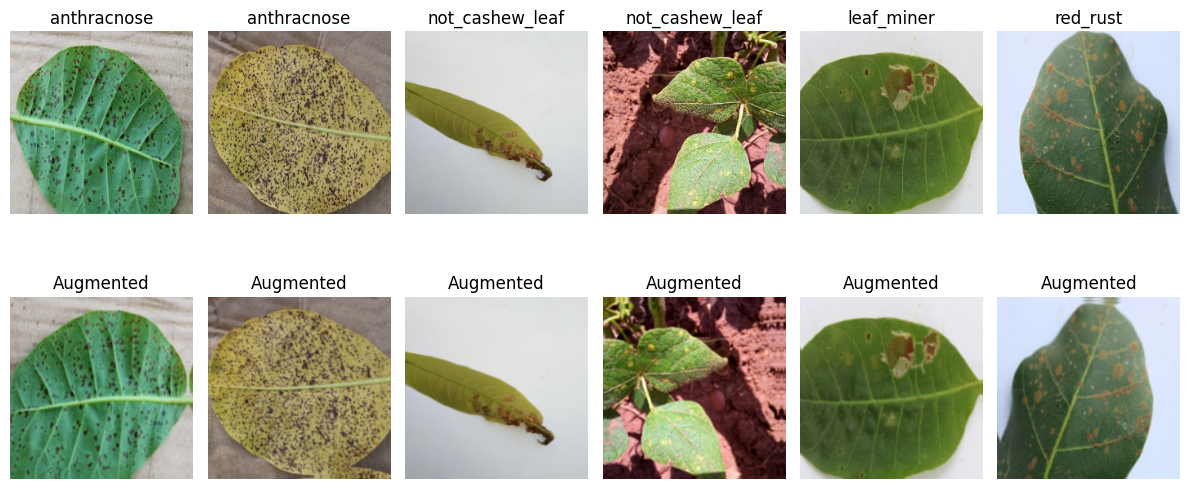

25467

In [10]:

# ============================================================
# 11. AUGMENTATION VISUAL CHECK
# ============================================================

preview_seed = SEEDS[0]

preview_ds = make_dataset(
    train_paths,
    train_labels,
    seed=preview_seed,
    training=True
)

preview_aug = build_data_augmentation(preview_seed)

for images, labels in preview_ds.take(1):

    n = min(6, int(images.shape[0]))

    plt.figure(figsize=(12, 6))

    for i in range(n):

        plt.subplot(2, 6, i + 1)
        plt.imshow(
            tf.cast(
                tf.clip_by_value(images[i], 0, 255),
                tf.uint8
            )
        )
        plt.title(CLASS_NAMES[int(labels[i])])
        plt.axis("off")

        aug_img = preview_aug(
            tf.expand_dims(images[i], 0),
            training=True
        )[0]

        plt.subplot(2, 6, i + 7)
        plt.imshow(
            tf.cast(
                tf.clip_by_value(aug_img, 0, 255),
                tf.uint8
            )
        )
        plt.title("Augmented")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

del preview_ds, preview_aug
gc.collect()


In [11]:
# ============================================================
# 12. SAVE EXPERIMENT CONFIG
# ============================================================

experiment_config = {
    "experiment_id": EXPERIMENT_ID,
    "notebook_version": NOTEBOOK_VERSION,
    "external_holdout_protocol": {
        "archive_name": REAL_HOLDOUT_ARCHIVE_NAME,
        "archive_sha256": REAL_HOLDOUT_ARCHIVE_SHA256,
        "expected_counts": REAL_HOLDOUT_EXPECTED_COUNTS,
        "gate": "RUN_FINAL_TEST and RUN_REAL_HOLDOUT",
        "separate_from_v05_test": True,
        "macro_scope": "true classes with holdout support; currently four",
        "selection_source": "validation only",
    },
    "created_at": datetime.now().isoformat(),
    "dataset": {
        "version": DATASET_VERSION,
        "path": str(DATASET_PATH),
        "classes": CLASS_NAMES,
        "train_images": len(train_paths),
        "val_images": len(val_paths),
        "test_images": len(test_paths),
        "total_images": len(valid_df),
        "test_set_locked": True,
    },
    "model": {
        "name": MODEL_NAME,
        "training_mode": TRAINING_MODE,
        "pretrained_weights": PRETRAINED_WEIGHTS,
        "input_size": [IMG_SIZE, IMG_SIZE, 3],
        "patch_size": PATCH_SIZE,
        "num_patches": NUM_PATCHES,
        "sequence_length": NUM_PATCHES + 1,
        "projection_dim": PROJECTION_DIM,
        "num_heads": NUM_HEADS,
        "transformer_layers": TRANSFORMER_LAYERS,
        "transformer_mlp_units": TRANSFORMER_MLP_UNITS,
        "attention_dropout": ATTENTION_DROPOUT,
        "transformer_dropout": TRANSFORMER_DROPOUT,
        "head_units": HEAD_UNITS,
        "head_dropout": HEAD_DROPOUT,
    },
    "training": {
        "seeds": SEEDS,
        "batch_size": BATCH_SIZE,
        "max_epochs": MAX_EPOCHS,
        "optimizer": "AdamW",
        "initial_learning_rate": INITIAL_LR,
        "weight_decay": WEIGHT_DECAY,
        "loss": "SparseCategoricalCrossentropy",
        "class_weight": None,
    },
    "augmentation": AUGMENTATION_CONFIG,
    "callbacks": {
        "checkpoint_monitor": "val_loss",
        "checkpoint_mode": "min",
        "checkpoint_type": "weights_only",
        "early_stopping_patience": EARLY_STOPPING_PATIENCE,
        "reduce_lr_patience": REDUCE_LR_PATIENCE,
        "reduce_lr_factor": REDUCE_LR_FACTOR,
        "min_lr": MIN_LR,
    },
    "test_protocol": {
        "run_final_test": RUN_FINAL_TEST,
        "final_test_completed": False,
        "same_locked_test_for_all_seeds": True,
        "do_not_select_best_seed_on_test": True,
        "summary": "mean ± sample standard deviation (ddof=1)",
    },
    "deployment_protocol": {
        "selection_source": "validation only",
        "selection_metric": "val_macro_f1",
        "tie_break": "lower val_loss",
        "test_used_for_deployment_seed_selection": False,
    },
    "archive": {
        "full_archive": f"{EXPERIMENT_ID}_FULL.zip",
        "analysis_archive": f"{EXPERIMENT_ID}_ANALYSIS.zip",
        "google_drive_target_url": DRIVE_TARGET_URL,
        "google_drive_target_folder_id": DRIVE_TARGET_FOLDER_ID,
    },
    "figure_protocol": {
        "seed_comparison_layout": "paper-style panel",
        "training_curves": "2 rows x 5 columns",
        "confusion_matrices": "1 row x 5 columns",
        "colormap": "Blues",
    },
    "hardware": {
        "gpu_count": len(gpus),
        "strategy": strategy.__class__.__name__,
        "replicas": strategy.num_replicas_in_sync,
    },
}

config_path = OUT_DIR / "experiment_config.json"
if config_path.exists():
    saved_config = json.loads(config_path.read_text(encoding="utf-8"))
    # EXP-005 predates the optional external-holdout metadata. Compare only the
    # frozen training/Validation sections needed to load its checkpoints safely.
    for key in ("dataset", "model", "training", "augmentation", "callbacks"):
        if key not in saved_config or saved_config[key] != experiment_config[key]:
            raise ValueError(f"Saved {key} differs from this notebook. Restore the frozen configuration.")
    experiment_config = saved_config
else:
    config_path.write_text(
        json.dumps(experiment_config, indent=2, ensure_ascii=False), encoding="utf-8"
    )

(OUT_DIR / "drive_target.json").write_text(
    json.dumps({
        "folder_url": DRIVE_TARGET_URL,
        "folder_id": DRIVE_TARGET_FOLDER_ID,
        "archive_name": f"{EXPERIMENT_ID}_FULL.zip",
    }, indent=2),
    encoding="utf-8"
)

print("Saved:", config_path)

Saved: /content/drive/MyDrive/Cashew_Leaf_model_result/training_results/current_dataset/EXP-VIT-SCRATCH-5SEEDS-005/experiment_config.json


## Locked real-world holdout (external Test)

Upload this notebook alone to Colab: the shared evaluator is embedded below, so no
additional Python module upload is necessary. On Colab the ZIP is read from
`MyDrive/Cashew_Leaf_model_result/Dataset/RL_Cashew_holdout.zip`.
Set `REAL_HOLDOUT_ARCHIVE_OVERRIDE` if your mounted location differs.
This preflight runs only when both Test flags permit it, before any Test prediction.

When Final Test is already enabled, this data-only check runs before costly training.
If enabling Test after training, run this preflight cell again before the Test drivers.


In [ ]:
"""Locked external classification evaluation; embedded in standalone notebooks.

This file has no training code. Holdout labels never select checkpoints or seeds.
"""

import hashlib
import json
import os
import stat
import time
import zipfile
from datetime import datetime, timezone
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap
from PIL import Image
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import f1_score, precision_score, recall_score


REAL_HOLDOUT_HELPER_VERSION = "006.1"
REAL_HOLDOUT_CMAP = LinearSegmentedColormap.from_list(
    "real_holdout_readable_blues", ["#ffffff", "#dbeafe", "#93c5fd"]
)


def holdout_sha256(path):
    digest = hashlib.sha256()
    with Path(path).open("rb") as stream:
        for block in iter(lambda: stream.read(1024 * 1024), b""):
            digest.update(block)
    return digest.hexdigest().upper()


def resolve_holdout_archive(archive_name, override=None):
    if override is not None:
        candidate = Path(override)
        if not candidate.is_file():
            raise FileNotFoundError(candidate)
        return candidate
    if Path("/content/drive/MyDrive").is_dir():
        candidate = Path("/content/drive/MyDrive/Cashew_Leaf_model_result/Dataset") / archive_name
        if candidate.is_file():
            return candidate
    if os.name == "nt":
        candidate = Path(r"D:\Study\KhoaLuanTotNghiep\Dataset") / archive_name
        if candidate.is_file():
            return candidate
    if Path("/kaggle/input").is_dir():
        candidates = sorted(Path("/kaggle/input").rglob(archive_name))
        if len(candidates) == 1:
            return candidates[0]
    raise FileNotFoundError(
        f"Cannot uniquely locate {archive_name}. Set REAL_HOLDOUT_ARCHIVE_OVERRIDE "
        "to the mounted ZIP path; on Colab add the supplied Dataset folder to My Drive."
    )


def prepare_real_holdout(archive_path, extraction_dir, class_names, expected_sha256,
                         expected_counts, reference_rows, audit_dir):
    """Verify the frozen archive, labels, decoding and byte overlap with V05.

    reference_rows: dictionaries with path/split and optional existing sha256.
    Exact-byte checking does not establish independence of near-duplicate photos.
    """
    archive_path, extraction_dir, audit_dir = map(Path, (archive_path, extraction_dir, audit_dir))
    actual_hash = holdout_sha256(archive_path)
    if actual_hash != expected_sha256.upper():
        raise ValueError(f"Holdout archive changed: {actual_hash}; expected {expected_sha256}.")
    marker = extraction_dir / ".archive_sha256"
    if extraction_dir.exists():
        if not marker.is_file() or marker.read_text(encoding="utf-8").strip() != actual_hash:
            raise FileExistsError(f"Unverified extraction: {extraction_dir}; choose a new directory.")
    else:
        with zipfile.ZipFile(archive_path) as archive:
            resolved_root = extraction_dir.resolve()
            for member in archive.infolist():
                target = (extraction_dir / member.filename.replace("\\", "/")).resolve()
                is_symlink = stat.S_ISLNK(member.external_attr >> 16)
                if is_symlink or (target != resolved_root and resolved_root not in target.parents):
                    raise ValueError(f"Unsafe ZIP member: {member.filename}")
            extraction_dir.mkdir(parents=True)
            archive.extractall(extraction_dir)
        marker.write_text(actual_hash, encoding="utf-8")

    dataset_root = extraction_dir / "RL_Cashew_holdout"
    if not dataset_root.is_dir():
        raise FileNotFoundError(dataset_root)
    found_classes = sorted(p.name for p in dataset_root.iterdir() if p.is_dir())
    if found_classes != sorted(expected_counts) or not set(found_classes).issubset(class_names):
        raise ValueError(f"Unexpected holdout class folders: {found_classes}")
    rows = []
    for label, name in enumerate(class_names):
        class_dir = dataset_root / name
        files = sorted(p for p in class_dir.rglob("*") if p.is_file()) if class_dir.is_dir() else []
        if len(files) != expected_counts.get(name, 0):
            raise ValueError(f"Unexpected holdout count for {name}: {len(files)}")
        for image_path in files:
            if image_path.suffix.lower() not in {".jpg", ".jpeg", ".png", ".bmp", ".webp"}:
                raise ValueError(f"Unsupported holdout image: {image_path}")
            with Image.open(image_path) as image:
                image.verify()
            with Image.open(image_path) as image:
                image.convert("RGB").load()
            rows.append({"path": str(image_path), "relative_path": image_path.relative_to(dataset_root).as_posix(),
                         "class": name, "label": label, "sha256": holdout_sha256(image_path)})
    manifest = pd.DataFrame(rows)
    if manifest.empty or manifest["sha256"].duplicated().any():
        raise ValueError("Holdout is empty or contains duplicate image bytes.")
    # A marker alone is insufficient: verify cached extraction bytes against the ZIP.
    with zipfile.ZipFile(archive_path) as frozen_archive:
        for row in rows:
            digest = hashlib.sha256()
            with frozen_archive.open("RL_Cashew_holdout/" + row["relative_path"]) as stream:
                for block in iter(lambda: stream.read(1024 * 1024), b""):
                    digest.update(block)
            if digest.hexdigest().upper() != row["sha256"]:
                raise ValueError(f"Cached holdout extraction changed: {row['relative_path']}")
    audit_dir.mkdir(parents=True, exist_ok=True)
    manifest.to_csv(audit_dir / "dataset_manifest.csv", index=False)

    references = list(reference_rows)
    if not references or not {"train", "val", "test"}.issubset({r["split"] for r in references}):
        raise ValueError("Overlap audit needs the full train/val/test V05 reference manifest.")
    holdout_hashes = set(manifest["sha256"])
    overlaps = []
    reference_digest = hashlib.sha256()
    for row in references:
        digest = row.get("sha256") or holdout_sha256(row["path"])
        digest = digest.upper()
        identity = row.get("relative_path", str(row["path"]))
        reference_digest.update(f"{row['split']}\0{identity}\0{digest}\n".encode("utf-8"))
        if digest in holdout_hashes:
            overlaps.append({"reference_path": str(row["path"]), "split": row["split"], "sha256": digest})
    present = [name for name in class_names if expected_counts.get(name, 0) > 0]
    audit = {"archive_sha256": actual_hash, "archive_name": archive_path.name,
             "manifest_sha256": hashlib.sha256(manifest[["relative_path", "class", "label", "sha256"]]
                 .to_csv(index=False).encode()).hexdigest(),
             "counts": {name: expected_counts.get(name, 0) for name in class_names},
             "images": len(manifest), "present_classes": present,
             "unsupported_classes": [name for name in class_names if name not in present],
             "reference_images_checked": len(references), "reference_fingerprint": reference_digest.hexdigest(),
             "byte_overlap_count": len(overlaps), "byte_overlaps": overlaps,
             "limitation": "Byte audit only; near-duplicate photos and shared trees/sessions need a separate audit."}
    (audit_dir / "dataset_audit.json").write_text(json.dumps(audit, indent=2), encoding="utf-8")
    if overlaps:
        raise ValueError("Real holdout overlaps V05 by exact bytes; inspect dataset_audit.json before evaluation.")
    print("Real holdout:", len(manifest), "images; present classes:", present)
    print("Not evaluated (no true examples):", audit["unsupported_classes"])
    return manifest, audit


def save_real_holdout_seed(manifest, probabilities, class_names, output_dir):
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    probabilities = np.asarray(probabilities, dtype=np.float64)
    if probabilities.shape != (len(manifest), len(class_names)) or not np.isfinite(probabilities).all():
        raise ValueError("Holdout predictions have invalid shape or non-finite values.")
    if (probabilities < 0).any() or not np.allclose(probabilities.sum(axis=1), 1, atol=1e-5):
        raise ValueError("Holdout evaluator expects probabilities, not logits.")
    y_true = manifest["label"].to_numpy(dtype=np.int32)
    y_pred = probabilities.argmax(axis=1)
    present_ids = sorted(set(y_true.tolist()))
    all_ids = list(range(len(class_names)))
    result = {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "macro_precision_present_classes": float(precision_score(y_true, y_pred, labels=present_ids, average="macro", zero_division=0)),
        "macro_recall_present_classes": float(recall_score(y_true, y_pred, labels=present_ids, average="macro", zero_division=0)),
        "macro_f1_present_classes": float(f1_score(y_true, y_pred, labels=present_ids, average="macro", zero_division=0)),
        "balanced_accuracy_present_classes": float(recall_score(y_true, y_pred, labels=present_ids, average="macro", zero_division=0)),
        "images": len(manifest), "macro_class_count": len(present_ids),
    }
    report = pd.DataFrame(classification_report(y_true, y_pred, labels=all_ids,
        target_names=class_names, output_dict=True, zero_division=0)).transpose()
    per_class = report.loc[class_names, ["precision", "recall", "f1-score", "support"]].copy()
    per_class["evaluated"] = per_class["support"] > 0
    # No evidence for unsupported true classes: don't present placeholder zeros as performance.
    per_class.loc[~per_class["evaluated"], ["precision", "recall", "f1-score"]] = np.nan
    per_class.to_csv(output_dir / "per_class_metrics.csv", index_label="class")
    readable_report = per_class.copy()
    readable_report["scope"] = np.where(readable_report["evaluated"], "true class present", "not evaluated: zero true support")
    readable_report.loc["macro avg (present classes)"] = [
        result["macro_precision_present_classes"], result["macro_recall_present_classes"],
        result["macro_f1_present_classes"], len(manifest), True,
        f"{len(present_ids)} supported true classes only",
    ]
    readable_report.loc["weighted avg"] = [
        report.loc["weighted avg", "precision"], report.loc["weighted avg", "recall"],
        report.loc["weighted avg", "f1-score"], len(manifest), True, "weighted by true support",
    ]
    readable_report.to_csv(output_dir / "classification_report.csv", index_label="class")
    predictions = manifest[["relative_path", "class", "label"]].copy()
    predictions["predicted_label"] = y_pred
    predictions["predicted_class"] = [class_names[i] for i in y_pred]
    predictions["confidence"] = probabilities.max(axis=1)
    predictions["correct"] = y_true == y_pred
    for label, name in enumerate(class_names):
        predictions[f"probability_{name}"] = probabilities[:, label]
    predictions.to_csv(output_dir / "predictions.csv", index=False)
    matrix = confusion_matrix(y_true, y_pred, labels=all_ids)
    for normalized, suffix in ((False, ""), (True, "_normalized")):
        values = matrix / np.maximum(matrix.sum(axis=1, keepdims=True), 1) if normalized else matrix
        pd.DataFrame(values, index=class_names, columns=class_names).to_csv(output_dir / f"confusion_matrix{suffix}.csv")
        fig, ax = plt.subplots(figsize=(9, 8), facecolor="white")
        ax.set_facecolor("white")
        ax.imshow(values, cmap=REAL_HOLDOUT_CMAP, vmin=0,
                  vmax=1 if normalized else max(int(matrix.max()), 1))
        ax.set_xticks(all_ids, class_names, rotation=40, ha="right", color="black")
        ax.set_yticks(all_ids, class_names, color="black")
        ax.set_xlabel("Predicted class", color="black")
        ax.set_ylabel("True class", color="black")
        ax.set_title("Real holdout" + (" (row normalized)" if normalized else ""), color="black")
        for row in all_ids:
            for col in all_ids:
                text = f"{values[row, col]:.2f}" if normalized else str(int(values[row, col]))
                if normalized and row not in present_ids:
                    text = "N/A"
                ax.text(col, row, text, ha="center", va="center", color="black")
        fig.tight_layout()
        fig.savefig(output_dir / f"confusion_matrix{suffix}.png", dpi=180)
        plt.close(fig)
    (output_dir / "metrics.json").write_text(json.dumps(result, indent=2), encoding="utf-8")
    return result


def evaluate_real_holdout(manifest, audit, class_names, seeds, validation_results,
                          checkpoints, load_model, make_dataset, clear_session,
                          output_dir, outputs_are_logits=False):
    """Freeze all checkpoints and validation selection BEFORE any prediction.

    Completed evaluations are read back, not repeated. Interrupted evaluations
    may resume only with the same checkpoint, validation and archive fingerprints.
    """
    output_dir = Path(output_dir)
    seeds = [int(seed) for seed in seeds]
    validation_results = validation_results.copy()
    if validation_results["seed"].tolist() != seeds:
        raise ValueError("Holdout evaluation requires completed, ordered validation for every seed.")
    if not np.isfinite(validation_results[["val_macro_f1", "val_loss"]].to_numpy()).all():
        raise ValueError("Validation selection metrics are incomplete.")
    ranked = validation_results.sort_values(["val_macro_f1", "val_loss", "seed"], ascending=[False, True, True])
    deployment_seed = int(ranked.iloc[0]["seed"])
    checkpoint_hashes = {str(seed): holdout_sha256(checkpoints[seed]) for seed in seeds}
    lock = {"helper_version": REAL_HOLDOUT_HELPER_VERSION, "archive_sha256": audit["archive_sha256"],
            "manifest_sha256": audit["manifest_sha256"],
            "reference_fingerprint": audit["reference_fingerprint"], "seeds": seeds,
            "checkpoint_sha256": checkpoint_hashes, "deployment_seed": deployment_seed,
            # Canonical float precision avoids false lock changes on CSV reload.
            "validation_sha256": hashlib.sha256(validation_results.to_csv(index=False, float_format="%.12g").encode()).hexdigest(),
            "model_classes": class_names, "macro_classes": audit["present_classes"],
            "selection_source": "validation only; macro F1, val_loss, seed tie-break",
            "outputs_are_logits": outputs_are_logits}
    lock_path = output_dir / "evaluation_lock.json"
    if lock_path.exists():
        if json.loads(lock_path.read_text(encoding="utf-8")) != lock:
            raise ValueError("Holdout lock changed. Do not retune using holdout or overwrite its results.")
    else:
        output_dir.mkdir(parents=True, exist_ok=True)
        lock_path.write_text(json.dumps(lock, indent=2), encoding="utf-8")
    aggregate_dir = output_dir / "aggregate"
    aggregate_dir.mkdir(exist_ok=True)
    results_path = aggregate_dir / "real_holdout_results_5seeds.csv"
    if (output_dir / "evaluation_completed.json").exists():
        print("Real holdout already completed; reading frozen results, not running predictions again.")
        return pd.read_csv(results_path)
    result_rows = []
    for seed in seeds:
        seed_dir = output_dir / f"seed_{seed}"
        completed_path = seed_dir / "evaluation_completed.json"
        if completed_path.exists():
            row = json.loads(completed_path.read_text(encoding="utf-8"))
        else:
            clear_session()
            model = load_model(seed)
            dataset = make_dataset(manifest)
            start = time.perf_counter()
            scores = np.asarray(model.predict(dataset, verbose=0))
            prediction_seconds = time.perf_counter() - start
            if outputs_are_logits:
                exponentials = np.exp(scores - scores.max(axis=1, keepdims=True))
                scores = exponentials / exponentials.sum(axis=1, keepdims=True)
            row = {"seed": seed, **save_real_holdout_seed(manifest, scores, class_names, seed_dir),
                   "prediction_seconds_including_input_pipeline": prediction_seconds}
            completed_path.write_text(json.dumps(row, indent=2), encoding="utf-8")
            del model, scores, dataset
            clear_session()
        result_rows.append(row)
    results = pd.DataFrame(result_rows)
    results.to_csv(results_path, index=False)
    metric_columns = [c for c in results if c not in {"seed", "images", "macro_class_count"}]
    results[metric_columns].agg(["mean", "std"]).transpose().to_csv(aggregate_dir / "real_holdout_mean_std.csv")
    per_class = pd.concat([pd.read_csv(output_dir / f"seed_{seed}" / "per_class_metrics.csv")
                          .assign(seed=seed) for seed in seeds], ignore_index=True)
    per_class.groupby("class")[["precision", "recall", "f1-score"]].agg(["mean", "std"]).to_csv(
        aggregate_dir / "per_class_real_holdout_mean_std.csv")
    deployment_result = next(row for row in result_rows if row["seed"] == deployment_seed)
    (aggregate_dir / "deployment_seed_result.json").write_text(json.dumps({
        "selection_source": "validation only, fixed before holdout", "result": deployment_result,
    }, indent=2), encoding="utf-8")
    (output_dir / "evaluation_completed.json").write_text(json.dumps({
        "completed_at_utc": datetime.now(timezone.utc).isoformat(),
        "note": "No model or seed selection on holdout. SD measures training-seed variability, not sampling uncertainty.",
    }, indent=2), encoding="utf-8")
    print("Real holdout results (macro metrics over supported true classes only):")
    print(results)
    return results

# --- Notebook-specific real holdout preflight (no prediction/training here) ---
if RUN_FINAL_TEST and RUN_REAL_HOLDOUT:
    holdout_archive = resolve_holdout_archive(REAL_HOLDOUT_ARCHIVE_NAME, REAL_HOLDOUT_ARCHIVE_OVERRIDE)
    holdout_reference_rows = valid_df.assign(
        relative_path=valid_df["path"].map(lambda path: Path(path).relative_to(DATASET_PATH).as_posix())
    ).to_dict("records")
    holdout_out_dir = OUT_DIR / "real_holdout"
    # Use runtime-local storage, not the Drive result directory, for images.
    if Path("/content").is_dir():
        holdout_extract_dir = Path("/content/real_holdout_006") / REAL_HOLDOUT_ARCHIVE_SHA256[:12]
    elif Path("/kaggle/working").is_dir():
        holdout_extract_dir = Path("/kaggle/working/real_holdout_006") / REAL_HOLDOUT_ARCHIVE_SHA256[:12]
    else:
        import tempfile
        holdout_extract_dir = Path(tempfile.gettempdir()) / "cashew_real_holdout_006" / REAL_HOLDOUT_ARCHIVE_SHA256[:12]
    real_holdout_manifest, real_holdout_audit = prepare_real_holdout(
        holdout_archive, holdout_extract_dir, CLASS_NAMES,
        REAL_HOLDOUT_ARCHIVE_SHA256, REAL_HOLDOUT_EXPECTED_COUNTS,
        holdout_reference_rows, holdout_out_dir,
    )
else:
    print("Real-world holdout remains locked; no holdout extraction/evaluation runs.")



# Train 5 Seeds

Cell tiếp theo chạy lần lượt:

```text
42 → 123 → 2026 → 3407 → 7777
```

Mỗi seed:
- tạo model mới hoàn toàn;
- train cùng một split;
- lưu `best.weights.h5` theo `val_loss`;
- lưu `history.csv`;
- lưu learning curves;
- sau train, **reload đúng best weights**;
- đánh giá Validation và lưu Macro-F1 / Balanced Accuracy / confusion matrix.

Test **không được đọc** trong cell này.


In [12]:

# ============================================================
# 13. TRAIN ALL 5 SEEDS
# ============================================================

training_rows = []
validation_rows = []

for run_index, seed in enumerate(SEEDS if RUN_TRAINING else [], start=1):

    print("\n" + "=" * 80)
    print(f"RUN {run_index}/{len(SEEDS)} - SEED {seed}")
    print("=" * 80)

    tf.keras.backend.clear_session()
    gc.collect()
    set_global_seed(seed)

    # --------------------------------------------------------
    # Folders
    # --------------------------------------------------------

    seed_dir = OUT_DIR / f"seed_{seed}"

    checkpoint_dir = seed_dir / "checkpoints"
    log_dir = seed_dir / "logs"
    figure_dir = seed_dir / "figures"
    validation_dir = seed_dir / "validation"

    for folder in [
        checkpoint_dir,
        log_dir,
        figure_dir,
        validation_dir,
    ]:
        folder.mkdir(parents=True, exist_ok=True)

    best_weights_path = (
        checkpoint_dir /
        f"VIT_SCRATCH_seed_{seed}_best.weights.h5"
    )
    if best_weights_path.exists() or (log_dir / "history.csv").exists():
        raise FileExistsError(f"Refusing to overwrite training outputs for seed {seed}.")

    # --------------------------------------------------------
    # Datasets
    # --------------------------------------------------------

    train_ds = make_dataset(
        train_paths,
        train_labels,
        seed=seed,
        training=True
    )

    val_ds = make_dataset(
        val_paths,
        val_labels,
        seed=seed,
        training=False
    )

    # --------------------------------------------------------
    # Build + compile
    # --------------------------------------------------------

    with strategy.scope():

        # CHỈ dùng function này.
        model = build_vit_model(seed)

        model.compile(
            optimizer=tf.keras.optimizers.AdamW(
                learning_rate=INITIAL_LR,
                weight_decay=WEIGHT_DECAY
            ),
            loss=tf.keras.losses.SparseCategoricalCrossentropy(),
            metrics=["accuracy"],
        )

    # --------------------------------------------------------
    # Model summary
    # --------------------------------------------------------

    summary_lines = []

    model.summary(
        print_fn=lambda line: summary_lines.append(line)
    )

    (
        seed_dir /
        "model_summary.txt"
    ).write_text(
        "\n".join(summary_lines),
        encoding="utf-8"
    )

    total_params = int(model.count_params())

    trainable_params = int(
        np.sum([
            np.prod(v.shape)
            for v in model.trainable_weights
        ])
    )

    non_trainable_params = int(
        total_params - trainable_params
    )

    # --------------------------------------------------------
    # Callbacks
    # --------------------------------------------------------

    callbacks = [

        tf.keras.callbacks.ModelCheckpoint(
            filepath=str(best_weights_path),
            monitor="val_loss",
            mode="min",
            save_best_only=True,
            save_weights_only=True,
            verbose=1,
        ),

        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            mode="min",
            patience=EARLY_STOPPING_PATIENCE,
            restore_best_weights=True,
            verbose=1,
        ),

        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            mode="min",
            factor=REDUCE_LR_FACTOR,
            patience=REDUCE_LR_PATIENCE,
            min_lr=MIN_LR,
            verbose=1,
        ),

        tf.keras.callbacks.CSVLogger(
            str(log_dir / "training_log.csv")
        ),
    ]

    # --------------------------------------------------------
    # Train
    # --------------------------------------------------------

    start_time = time.perf_counter()

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=MAX_EPOCHS,
        callbacks=callbacks,
        verbose=1,
    )

    training_time_seconds = time.perf_counter() - start_time

    # --------------------------------------------------------
    # History
    # --------------------------------------------------------

    history_df = pd.DataFrame(history.history)

    history_df.insert(
        0,
        "epoch",
        np.arange(1, len(history_df) + 1)
    )

    history_df.to_csv(
        log_dir / "history.csv",
        index=False
    )

    actual_epochs = len(history_df)

    best_epoch = int(
        np.argmin(history.history["val_loss"])
    ) + 1

    best_val_loss_history = float(
        np.min(history.history["val_loss"])
    )

    best_val_accuracy_history = float(
        history.history["val_accuracy"][best_epoch - 1]
    )

    # --------------------------------------------------------
    # Curves
    # --------------------------------------------------------

    plt.figure(figsize=(8, 5))

    plt.plot(
        history_df["epoch"],
        history_df["accuracy"],
        label="Train"
    )

    plt.plot(
        history_df["epoch"],
        history_df["val_accuracy"],
        label="Validation"
    )

    plt.axvline(
        best_epoch,
        linestyle="--",
        label=f"Best epoch = {best_epoch}"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"Vision Transformer Scratch - Seed {seed} - Accuracy")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()

    plt.savefig(
        figure_dir / "accuracy_curve.png",
        dpi=200,
        bbox_inches="tight"
    )

    plt.close()

    plt.figure(figsize=(8, 5))

    plt.plot(
        history_df["epoch"],
        history_df["loss"],
        label="Train"
    )

    plt.plot(
        history_df["epoch"],
        history_df["val_loss"],
        label="Validation"
    )

    plt.axvline(
        best_epoch,
        linestyle="--",
        label=f"Best epoch = {best_epoch}"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"Vision Transformer Scratch - Seed {seed} - Loss")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()

    plt.savefig(
        figure_dir / "loss_curve.png",
        dpi=200,
        bbox_inches="tight"
    )

    plt.close()

    # --------------------------------------------------------
    # IMPORTANT:
    # Reload exactly the checkpoint chosen by minimum val_loss.
    # --------------------------------------------------------

    model.load_weights(best_weights_path)

    # --------------------------------------------------------
    # Validation evaluation
    # --------------------------------------------------------

    val_loss, val_accuracy = model.evaluate(
        val_ds,
        verbose=0
    )

    y_val_true = []
    y_val_prob = []

    for images, labels in val_ds:

        probs = model.predict(
            images,
            verbose=0
        )

        y_val_prob.append(probs)
        y_val_true.append(labels.numpy())

    y_val_true = np.concatenate(y_val_true)
    y_val_prob = np.concatenate(y_val_prob)
    y_val_pred = np.argmax(y_val_prob, axis=1)
    y_val_conf = np.max(y_val_prob, axis=1)

    val_metrics = {
        "seed": seed,
        "val_loss": float(val_loss),
        "val_accuracy": float(
            accuracy_score(y_val_true, y_val_pred)
        ),
        "val_macro_precision": float(
            precision_score(
                y_val_true,
                y_val_pred,
                average="macro",
                zero_division=0
            )
        ),
        "val_macro_recall": float(
            recall_score(
                y_val_true,
                y_val_pred,
                average="macro",
                zero_division=0
            )
        ),
        "val_macro_f1": float(
            f1_score(
                y_val_true,
                y_val_pred,
                average="macro",
                zero_division=0
            )
        ),
        "val_balanced_accuracy": float(
            balanced_accuracy_score(
                y_val_true,
                y_val_pred
            )
        ),
    }

    validation_rows.append(val_metrics)

    # --------------------------------------------------------
    # Validation classification report
    # --------------------------------------------------------

    val_report_df = pd.DataFrame(
        classification_report(
            y_val_true,
            y_val_pred,
            target_names=CLASS_NAMES,
            output_dict=True,
            zero_division=0,
        )
    ).transpose()

    val_report_df.to_csv(
        validation_dir /
        "classification_report.csv"
    )

    # --------------------------------------------------------
    # Validation confusion matrix
    # --------------------------------------------------------

    val_cm = confusion_matrix(
        y_val_true,
        y_val_pred
    )

    val_cm_norm = confusion_matrix(
        y_val_true,
        y_val_pred,
        normalize="true"
    )

    pd.DataFrame(
        val_cm,
        index=CLASS_NAMES,
        columns=CLASS_NAMES
    ).to_csv(
        validation_dir /
        "confusion_matrix.csv"
    )

    pd.DataFrame(
        val_cm_norm,
        index=CLASS_NAMES,
        columns=CLASS_NAMES
    ).to_csv(
        validation_dir /
        "confusion_matrix_normalized.csv"
    )

    fig, ax = plt.subplots(figsize=(8, 7))

    matrix_display = ConfusionMatrixDisplay(
        confusion_matrix=val_cm,
        display_labels=CLASS_NAMES
    ).plot(
        ax=ax,
        cmap=MATRIX_CMAP,
        values_format="d",
        colorbar=False
    )
    for label in matrix_display.text_.ravel():
        label.set_color("black")

    plt.title(
        f"Validation Confusion Matrix - Seed {seed}"
    )

    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()

    plt.savefig(
        validation_dir /
        "confusion_matrix.png",
        dpi=200,
        bbox_inches="tight"
    )

    plt.close()

    # --------------------------------------------------------
    # Validation predictions
    # --------------------------------------------------------

    val_predictions_df = pd.DataFrame({
        "filename": val_meta["path"],
        "true_label": [
            CLASS_NAMES[int(i)]
            for i in y_val_true
        ],
        "predicted_label": [
            CLASS_NAMES[int(i)]
            for i in y_val_pred
        ],
        "confidence": y_val_conf,
        "correct": y_val_true == y_val_pred,
    })

    val_predictions_df.to_csv(
        validation_dir /
        "predictions.csv",
        index=False
    )

    # --------------------------------------------------------
    # Training summary
    # --------------------------------------------------------

    row = {
        "seed": seed,
        "actual_epochs": actual_epochs,
        "best_epoch": best_epoch,
        "best_val_loss_history": best_val_loss_history,
        "best_val_accuracy_history": best_val_accuracy_history,
        "checkpoint_val_loss": float(val_loss),
        "checkpoint_val_accuracy": float(val_metrics["val_accuracy"]),
        "checkpoint_val_macro_f1": float(val_metrics["val_macro_f1"]),
        "checkpoint_val_balanced_accuracy": float(
            val_metrics["val_balanced_accuracy"]
        ),
        "training_time_seconds": float(training_time_seconds),
        "total_parameters": total_params,
        "trainable_parameters": trainable_params,
        "non_trainable_parameters": non_trainable_params,
        "best_weights_path": str(best_weights_path),
        "best_weights_size_mb": float(
            best_weights_path.stat().st_size /
            (1024 ** 2)
        ),
    }

    training_rows.append(row)

    (
        seed_dir /
        "training_summary.json"
    ).write_text(
        json.dumps(
            row,
            indent=2
        ),
        encoding="utf-8"
    )

    print("\nSeed summary:")
    print(json.dumps(row, indent=2))

    # --------------------------------------------------------
    # Cleanup
    # --------------------------------------------------------

    del model
    del train_ds
    del val_ds
    del history

    tf.keras.backend.clear_session()
    gc.collect()


if RUN_TRAINING:
    training_summary_df = pd.DataFrame(training_rows)
    validation_results_df = pd.DataFrame(validation_rows)
else:
    training_summary_df = pd.read_csv(AGGREGATE_DIR / "training_summary_5seeds.csv")
    validation_results_df = pd.read_csv(AGGREGATE_DIR / "validation_results_5seeds.csv")
    if training_summary_df["seed"].tolist() != SEEDS or validation_results_df["seed"].tolist() != SEEDS:
        raise ValueError("Saved training/validation results must contain all configured seeds.")

if RUN_TRAINING:
    training_summary_df.to_csv(AGGREGATE_DIR / "training_summary_5seeds.csv", index=False)
    validation_results_df.to_csv(AGGREGATE_DIR / "validation_results_5seeds.csv", index=False)

# Wall time around model.fit includes epoch validation and callbacks.
training_times = training_summary_df["training_time_seconds"]
training_time_summary = pd.DataFrame({
    "metric": ["training_time_seconds", "training_time_minutes"],
    "mean": [training_times.mean(), training_times.mean() / 60],
    "std": [training_times.std(ddof=1), training_times.std(ddof=1) / 60],
    "total": [training_times.sum(), training_times.sum() / 60],
})
training_time_summary.to_csv(AGGREGATE_DIR / "training_time_mean_std_summary.csv", index=False)
print("\nTraining time across seeds:")
display(training_time_summary)

print("\nTraining summary:")
display(training_summary_df)

print("\nValidation metrics:")
display(validation_results_df)



Training time across seeds:


,metric,mean,std,total
0,training_time_seconds,371.72519,63.690818,1858.625951
1,training_time_minutes,6.19542,1.061514,30.977099



Training summary:


,seed,actual_epochs,best_epoch,best_val_loss_history,best_val_accuracy_history,checkpoint_val_loss,checkpoint_val_accuracy,checkpoint_val_macro_f1,checkpoint_val_balanced_accuracy,training_time_seconds,total_parameters,trainable_parameters,non_trainable_parameters,best_weights_path,best_weights_size_mb
0,42,47,37,0.321538,0.889444,0.321538,0.889444,0.883481,0.879751,480.428247,347717,347717,0,/content/drive/MyDrive/Cashew_Leaf_model_resul...,4.413239
1,123,36,26,0.389828,0.868046,0.389828,0.868046,0.861949,0.859454,369.990195,347717,347717,0,/content/drive/MyDrive/Cashew_Leaf_model_resul...,4.413239
2,2026,31,21,0.350799,0.878031,0.350799,0.878031,0.873052,0.872388,320.973827,347717,347717,0,/content/drive/MyDrive/Cashew_Leaf_model_resul...,4.413239
3,3407,32,22,0.303734,0.905136,0.303734,0.905136,0.901644,0.898690,332.417350,347717,347717,0,/content/drive/MyDrive/Cashew_Leaf_model_resul...,4.413239
4,7777,34,24,0.375512,0.875892,0.375512,0.875892,0.870538,0.866395,354.816332,347717,347717,0,/content/drive/MyDrive/Cashew_Leaf_model_resul...,4.413239



Validation metrics:


,seed,val_loss,val_accuracy,val_macro_precision,val_macro_recall,val_macro_f1,val_balanced_accuracy
0,42,0.321538,0.889444,0.891110,0.879751,0.883481,0.879751
1,123,0.389828,0.868046,0.867000,0.859454,0.861949,0.859454
2,2026,0.350799,0.878031,0.874757,0.872388,0.873052,0.872388
3,3407,0.303734,0.905136,0.906889,0.898690,0.901644,0.898690
4,7777,0.375512,0.875892,0.880880,0.866395,0.870538,0.866395


In [13]:

# ============================================================
# 14. VALIDATION MEAN ± STD
# ============================================================

validation_metrics_to_summarize = [
    "val_accuracy",
    "val_macro_precision",
    "val_macro_recall",
    "val_macro_f1",
    "val_balanced_accuracy",
]

validation_summary_rows = []

for metric in validation_metrics_to_summarize:

    values = validation_results_df[metric]

    validation_summary_rows.append({
        "metric": metric,
        "mean": float(values.mean()),
        "std": float(values.std(ddof=1)),
        "report": (
            f"{values.mean()*100:.2f} ± "
            f"{values.std(ddof=1)*100:.2f}%"
        ),
    })

validation_mean_std_df = pd.DataFrame(
    validation_summary_rows
)

display(validation_mean_std_df)

validation_mean_std_df.to_csv(
    AGGREGATE_DIR /
    "validation_mean_std_summary.csv",
    index=False
)

print("\nBest epoch across seeds:")
print(
    f"{training_summary_df['best_epoch'].mean():.2f} ± "
    f"{training_summary_df['best_epoch'].std(ddof=1):.2f}"
)


,metric,mean,std,report
0,val_accuracy,0.883310,0.014404,88.33 ± 1.44%
1,val_macro_precision,0.884127,0.015480,88.41 ± 1.55%
2,val_macro_recall,0.875335,0.015048,87.53 ± 1.50%
3,val_macro_f1,0.878133,0.015222,87.81 ± 1.52%
4,val_balanced_accuracy,0.875335,0.015048,87.53 ± 1.50%



Best epoch across seeds:
26.00 ± 6.44


In [ ]:
# ============================================================
# 14B. PAPER-STYLE 5-SEED VALIDATION PANELS
# ============================================================

# A. Training curves — 2 rows x 5 seed columns
histories = {}
for seed in SEEDS:
    history_path = OUT_DIR / f"seed_{seed}" / "logs" / "history.csv"
    histories[seed] = pd.read_csv(history_path)

fig, axes = plt.subplots(
    2,
    len(SEEDS),
    figsize=(27, 9),
    sharey="row"
)

all_losses = []
for seed in SEEDS:
    all_losses.extend(histories[seed]["loss"].tolist())
    all_losses.extend(histories[seed]["val_loss"].tolist())

loss_upper = max(all_losses) * 1.05

for col, seed in enumerate(SEEDS):
    hist = histories[seed]
    best_epoch = int(hist.loc[hist["val_loss"].idxmin(), "epoch"])

    axes[0, col].plot(hist["epoch"], hist["accuracy"], label="Train")
    axes[0, col].plot(hist["epoch"], hist["val_accuracy"], label="Validation")
    axes[0, col].axvline(best_epoch, linestyle="--")
    axes[0, col].set_title(f"Seed {seed}", fontweight="bold")
    axes[0, col].set_xlabel("Epoch")
    axes[0, col].set_ylim(0, 1)
    axes[0, col].grid(alpha=0.25)

    axes[1, col].plot(hist["epoch"], hist["loss"], label="Train")
    axes[1, col].plot(hist["epoch"], hist["val_loss"], label="Validation")
    axes[1, col].axvline(best_epoch, linestyle="--")
    axes[1, col].set_xlabel("Epoch")
    axes[1, col].set_ylim(0, loss_upper)
    axes[1, col].grid(alpha=0.25)

axes[0, 0].set_ylabel("Accuracy")
axes[1, 0].set_ylabel("Loss")
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=2)
fig.suptitle(
    "Vision Transformer Scratch - Training Curves Across 5 Seeds",
    y=1.02,
    fontsize=16,
    fontweight="bold"
)
fig.tight_layout()

training_panel_path = PANEL_DIR / "training_curves_5seeds_panel.png"
fig.savefig(training_panel_path, dpi=220, bbox_inches="tight")
plt.close(fig)

# B. Normalized Validation confusion matrices — 1 x 5
fig, axes = plt.subplots(
    1,
    len(SEEDS),
    figsize=(30, 6.5),
    constrained_layout=True
)

last_im = None

for col, seed in enumerate(SEEDS):
    cm_path = (
        OUT_DIR / f"seed_{seed}" / "validation" /
        "confusion_matrix_normalized.csv"
    )
    cm = pd.read_csv(cm_path, index_col=0).to_numpy()
    ax = axes[col]

    last_im = ax.imshow(
        cm,
        cmap=MATRIX_CMAP,
        vmin=0.0,
        vmax=1.0,
        aspect="equal"
    )

    ax.set_title(f"Seed {seed}", fontsize=13, fontweight="bold", pad=12)
    ax.set_xticks(range(NUM_CLASSES))
    ax.set_yticks(range(NUM_CLASSES))
    ax.set_xticklabels(CLASS_NAMES, rotation=40, ha="right", fontsize=9)

    if col == 0:
        ax.set_yticklabels(CLASS_NAMES, fontsize=9)
        ax.set_ylabel("True label", fontsize=11)
    else:
        ax.set_yticklabels([])

    ax.set_xlabel("Predicted label", fontsize=10)

    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            value = float(cm[i, j])
            text_color = "black"
            ax.text(
                j,
                i,
                f"{value:.2f}",
                ha="center",
                va="center",
                fontsize=9,
                fontweight="bold",
                color=text_color
            )

    for spine in ax.spines.values():
        spine.set_visible(False)

cbar = fig.colorbar(last_im, ax=axes, fraction=0.018, pad=0.015)
cbar.set_label("Row-normalized proportion", fontsize=10)

fig.suptitle(
    "Vision Transformer Scratch - Validation Normalized Confusion Matrices Across 5 Seeds",
    fontsize=16,
    fontweight="bold"
)

validation_panel_path = PANEL_DIR / "validation_confusion_matrices_5seeds_panel.png"
fig.savefig(validation_panel_path, dpi=220, bbox_inches="tight")
plt.close(fig)

print("Created:", training_panel_path)
print("Created:", validation_panel_path)
display(Image.open(training_panel_path))


# FINAL TEST GATE

**Dừng ở đây nếu bạn chưa muốn mở Test Set.**

Sau khi 5 seeds đã train xong và bạn xác nhận cấu hình không thay đổi nữa:

1. quay lại Cell `03. CONFIGURATION`;
2. đổi:

```python
RUN_FINAL_TEST = True
```

3. chạy lại Cell 03;
4. **không chạy lại Cell Train**;
5. chạy từ cell `15. FINAL TEST` trở xuống.

Final Test sẽ build lại đúng architecture cho từng seed, load `best.weights.h5`, rồi đánh giá cùng một Test Set đã khóa.


In [14]:

# ============================================================
# 15. FINAL TEST - 5 SEEDS
# ============================================================

test_result_rows = []

if not RUN_FINAL_TEST:

    print(
        "FINAL TEST IS LOCKED.\n"
        "RUN_FINAL_TEST = False\n"
        "Không đánh giá Test trong lần chạy này."
    )

else:

    test_ds = make_dataset(
        test_paths,
        test_labels,
        seed=SEEDS[0],
        training=False
    )

    for run_index, seed in enumerate(SEEDS, start=1):

        print("\n" + "=" * 80)
        print(
            f"FINAL TEST {run_index}/{len(SEEDS)} - SEED {seed}"
        )
        print("=" * 80)

        tf.keras.backend.clear_session()
        gc.collect()
        set_global_seed(seed)

        seed_dir = OUT_DIR / f"seed_{seed}"

        best_weights_path = (
            seed_dir /
            "checkpoints" /
            f"VIT_SCRATCH_seed_{seed}_best.weights.h5"
        )

        if not best_weights_path.exists():
            raise FileNotFoundError(
                f"Missing checkpoint: {best_weights_path}"
            )

        metric_dir = seed_dir / "test_metrics"
        figure_dir = seed_dir / "test_figures"
        prediction_dir = seed_dir / "test_predictions"
        error_dir = prediction_dir / "error_cases"

        for folder in [
            metric_dir,
            figure_dir,
            prediction_dir,
            error_dir,
        ]:
            folder.mkdir(
                parents=True,
                exist_ok=True
            )

        # ----------------------------------------------------
        # Rebuild exact architecture and load best weights
        # ----------------------------------------------------

        with strategy.scope():

            model = build_vit_model(seed)

            # Load weights BEFORE compile so Final Test does not
            # attempt to restore stale optimizer variables.
            model.load_weights(
                best_weights_path
            )

            model.compile(
                optimizer=tf.keras.optimizers.AdamW(
                    learning_rate=INITIAL_LR,
                    weight_decay=WEIGHT_DECAY
                ),
                loss=tf.keras.losses.SparseCategoricalCrossentropy(),
                metrics=["accuracy"],
            )

        # ----------------------------------------------------
        # Evaluate
        # ----------------------------------------------------

        test_loss, test_accuracy_keras = model.evaluate(
            test_ds,
            verbose=0
        )

        # Warm-up bằng nguyên batch đầu tiên.
        # Không dùng batch=1 khi MirroredStrategy có nhiều GPU.
        _ = model.predict(
            test_ds.take(1),
            verbose=0
        )

        prediction_start = time.perf_counter()

        # Predict toàn bộ Test Dataset trong một call để giảm overhead
        # và cho phép MirroredStrategy tự phân phối batch ổn định.
        y_prob = model.predict(
            test_ds,
            verbose=0
        )

        prediction_time = (
            time.perf_counter() -
            prediction_start
        )

        # Test dataset không shuffle nên thứ tự prediction
        # trùng với test_labels.
        y_true = np.asarray(
            test_labels,
            dtype=np.int32
        )

        y_pred = np.argmax(
            y_prob,
            axis=1
        )

        confidences = np.max(
            y_prob,
            axis=1
        )

        # ----------------------------------------------------
        # Metrics
        # ----------------------------------------------------

        accuracy = accuracy_score(
            y_true,
            y_pred
        )

        macro_precision = precision_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0
        )

        macro_recall = recall_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0
        )

        macro_f1 = f1_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0
        )

        balanced_acc = balanced_accuracy_score(
            y_true,
            y_pred
        )

        weighted_precision = precision_score(
            y_true,
            y_pred,
            average="weighted",
            zero_division=0
        )

        weighted_recall = recall_score(
            y_true,
            y_pred,
            average="weighted",
            zero_division=0
        )

        weighted_f1 = f1_score(
            y_true,
            y_pred,
            average="weighted",
            zero_division=0
        )

        inference_ms = (
            prediction_time /
            len(y_true)
        ) * 1000.0

        fps = (
            len(y_true) /
            prediction_time
        )

        # ----------------------------------------------------
        # Reports
        # ----------------------------------------------------

        report_df = pd.DataFrame(
            classification_report(
                y_true,
                y_pred,
                target_names=CLASS_NAMES,
                output_dict=True,
                zero_division=0,
            )
        ).transpose()

        report_df.to_csv(
            metric_dir /
            "classification_report.csv"
        )

        cm = confusion_matrix(
            y_true,
            y_pred
        )

        cm_norm = confusion_matrix(
            y_true,
            y_pred,
            normalize="true"
        )

        pd.DataFrame(
            cm,
            index=CLASS_NAMES,
            columns=CLASS_NAMES
        ).to_csv(
            metric_dir /
            "confusion_matrix.csv"
        )

        pd.DataFrame(
            cm_norm,
            index=CLASS_NAMES,
            columns=CLASS_NAMES
        ).to_csv(
            metric_dir /
            "confusion_matrix_normalized.csv"
        )

        # ----------------------------------------------------
        # Confusion matrix figures
        # ----------------------------------------------------

        fig, ax = plt.subplots(figsize=(8, 7))

        matrix_display = ConfusionMatrixDisplay(
            confusion_matrix=cm,
            display_labels=CLASS_NAMES
        ).plot(
            ax=ax,
            cmap=MATRIX_CMAP,
            values_format="d",
            colorbar=False
        )
        for label in matrix_display.text_.ravel():
            label.set_color("black")

        plt.title(
            f"Test Confusion Matrix - Seed {seed}"
        )

        plt.xticks(rotation=30, ha="right")
        plt.tight_layout()

        plt.savefig(
            figure_dir /
            "confusion_matrix.png",
            dpi=200,
            bbox_inches="tight"
        )

        plt.close()

        fig, ax = plt.subplots(figsize=(8, 7))

        matrix_display = ConfusionMatrixDisplay(
            confusion_matrix=cm_norm,
            display_labels=CLASS_NAMES
        ).plot(
            ax=ax,
            cmap=MATRIX_CMAP,
            values_format=".2f",
            colorbar=False
        )
        for label in matrix_display.text_.ravel():
            label.set_color("black")

        plt.title(
            f"Normalized Test Confusion Matrix - Seed {seed}"
        )

        plt.xticks(rotation=30, ha="right")
        plt.tight_layout()

        plt.savefig(
            figure_dir /
            "confusion_matrix_normalized.png",
            dpi=200,
            bbox_inches="tight"
        )

        plt.close()

        # ----------------------------------------------------
        # Prediction CSV
        # ----------------------------------------------------

        predictions_df = pd.DataFrame({
            "filename": test_meta["path"],
            "true_label": [
                CLASS_NAMES[int(i)]
                for i in y_true
            ],
            "predicted_label": [
                CLASS_NAMES[int(i)]
                for i in y_pred
            ],
            "confidence": confidences,
            "correct": y_true == y_pred,
        })

        predictions_df.to_csv(
            prediction_dir /
            "predictions.csv",
            index=False
        )

        wrong_df = (
            predictions_df[
                ~predictions_df["correct"]
            ]
            .sort_values(
                "confidence",
                ascending=False
            )
        )

        wrong_df.head(20).to_csv(
            error_dir /
            "highest_confidence_wrong.csv",
            index=False
        )

        correct_low_conf = (
            predictions_df[
                predictions_df["correct"]
            ]
            .sort_values(
                "confidence",
                ascending=True
            )
        )

        correct_low_conf.head(20).to_csv(
            error_dir /
            "lowest_confidence_correct.csv",
            index=False
        )

        # ----------------------------------------------------
        # Seed metrics
        # ----------------------------------------------------

        seed_metrics = {
            "seed": seed,
            "test_loss": float(test_loss),
            "accuracy": float(accuracy),
            "macro_precision": float(macro_precision),
            "macro_recall": float(macro_recall),
            "macro_f1": float(macro_f1),
            "balanced_accuracy": float(balanced_acc),
            "weighted_precision": float(weighted_precision),
            "weighted_recall": float(weighted_recall),
            "weighted_f1": float(weighted_f1),
            "weights_size_mb": float(
                best_weights_path.stat().st_size /
                (1024 ** 2)
            ),
            "inference_time_ms_per_image": float(inference_ms),
            "fps": float(fps),
        }

        (
            metric_dir /
            "metrics.json"
        ).write_text(
            json.dumps(
                seed_metrics,
                indent=2
            ),
            encoding="utf-8"
        )

        test_result_rows.append(
            seed_metrics
        )

        print(json.dumps(seed_metrics, indent=2))

        del model
        tf.keras.backend.clear_session()
        gc.collect()


    test_results_df = pd.DataFrame(
        test_result_rows
    )

    test_results_df.to_csv(
        AGGREGATE_DIR /
        "aggregate_test_results.csv",
        index=False
    )

    display(test_results_df)



FINAL TEST 1/5 - SEED 42
Global seed set to: 42
Global seed set to: 42
{
  "seed": 42,
  "test_loss": 0.4467598795890808,
  "accuracy": 0.8471615720524017,
  "macro_precision": 0.8399292920892469,
  "macro_recall": 0.8383151348038966,
  "macro_f1": 0.836884913398589,
  "balanced_accuracy": 0.8383151348038966,
  "weighted_precision": 0.8515182734273354,
  "weighted_recall": 0.8471615720524017,
  "weighted_f1": 0.8473808638172443,
  "weights_size_mb": 4.413238525390625,
  "inference_time_ms_per_image": 2.228174017467717,
  "fps": 448.7979808401515
}

FINAL TEST 2/5 - SEED 123
Global seed set to: 123
Global seed set to: 123
{
  "seed": 123,
  "test_loss": 0.44225096702575684,
  "accuracy": 0.8442503639010189,
  "macro_precision": 0.8428567089550214,
  "macro_recall": 0.8371760534620751,
  "macro_f1": 0.8341894045868334,
  "balanced_accuracy": 0.8371760534620751,
  "weighted_precision": 0.8520110375292401,
  "weighted_recall": 0.8442503639010189,
  "weighted_f1": 0.8429020199488975,
  "we

,seed,test_loss,accuracy,macro_precision,macro_recall,macro_f1,balanced_accuracy,weighted_precision,weighted_recall,weighted_f1,weights_size_mb,inference_time_ms_per_image,fps
0,42,0.446760,0.847162,0.839929,0.838315,0.836885,0.838315,0.851518,0.847162,0.847381,4.413239,2.228174,448.797981
1,123,0.442251,0.844250,0.842857,0.837176,0.834189,0.837176,0.852011,0.844250,0.842902,4.413239,2.286772,437.297601
2,2026,0.396093,0.852984,0.848225,0.845655,0.843221,0.845655,0.862105,0.852984,0.854201,4.413239,2.228840,448.663853
3,3407,0.411845,0.854440,0.843993,0.842941,0.841268,0.842941,0.853856,0.854440,0.852169,4.413239,2.238620,446.703826
4,7777,0.395733,0.852984,0.842732,0.841916,0.840925,0.841916,0.849979,0.852984,0.850134,4.413239,2.251989,444.051901


In [15]:

# ============================================================
# 16. TEST MEAN ± STD + THESIS TABLE
# ============================================================

if not RUN_FINAL_TEST:

    print(
        "Skipped: Final Test chưa chạy."
    )

else:

    summary_metrics = [
        "accuracy",
        "macro_precision",
        "macro_recall",
        "macro_f1",
        "balanced_accuracy",
        "weighted_f1",
        "inference_time_ms_per_image",
        "fps",
    ]

    summary_rows = []

    for metric in summary_metrics:

        values = test_results_df[metric]

        summary_rows.append({
            "metric": metric,
            "mean": float(values.mean()),
            "std": float(values.std(ddof=1)),
            "report": (
                f"{values.mean():.6f} ± "
                f"{values.std(ddof=1):.6f}"
            ),
        })

    mean_std_df = pd.DataFrame(
        summary_rows
    )

    display(mean_std_df)

    mean_std_df.to_csv(
        AGGREGATE_DIR /
        "test_mean_std_summary.csv",
        index=False
    )

    thesis_metrics = [
        "accuracy",
        "macro_precision",
        "macro_recall",
        "macro_f1",
        "balanced_accuracy",
        "weighted_f1",
    ]

    thesis_rows = []

    for metric in thesis_metrics:

        values = (
            test_results_df[metric]
            * 100
        )

        thesis_rows.append({
            "Metric": metric,
            "Mean (%)": float(values.mean()),
            "Std (%)": float(values.std(ddof=1)),
            "Report": (
                f"{values.mean():.2f} ± "
                f"{values.std(ddof=1):.2f}%"
            ),
        })

    thesis_summary_df = pd.DataFrame(
        thesis_rows
    )

    print("\nThesis-ready table:")
    display(thesis_summary_df)

    thesis_summary_df.to_csv(
        AGGREGATE_DIR /
        "thesis_test_mean_std_summary.csv",
        index=False
    )

    aggregate_metrics = {
        "experiment_id": EXPERIMENT_ID,
        "model": MODEL_NAME,
        "training_mode": TRAINING_MODE,
        "dataset": DATASET_VERSION,
        "seeds": SEEDS,
        "num_seeds": len(SEEDS),
        "std_definition": "sample standard deviation (ddof=1)",
        "test_set_locked": True,
        "per_seed_results": test_result_rows,
        "summary": {
            row["metric"]: {
                "mean": float(row["mean"]),
                "std": float(row["std"]),
            }
            for row in summary_rows
        },
    }

    (
        AGGREGATE_DIR /
        "aggregate_test_metrics.json"
    ).write_text(
        json.dumps(
            aggregate_metrics,
            indent=2
        ),
        encoding="utf-8"
    )


,metric,mean,std,report
0,accuracy,0.850364,0.004415,0.850364 ± 0.004415
1,macro_precision,0.843547,0.003013,0.843547 ± 0.003013
2,macro_recall,0.841201,0.003461,0.841201 ± 0.003461
3,macro_f1,0.839298,0.003669,0.839298 ± 0.003669
4,balanced_accuracy,0.841201,0.003461,0.841201 ± 0.003461
5,weighted_f1,0.849357,0.004403,0.849357 ± 0.004403
6,inference_time_ms_per_image,2.246879,0.024295,2.246879 ± 0.024295
7,fps,445.103032,4.767711,445.103032 ± 4.767711



Thesis-ready table:


,Metric,Mean (%),Std (%),Report
0,accuracy,85.036390,0.441507,85.04 ± 0.44%
1,macro_precision,84.354728,0.301310,84.35 ± 0.30%
2,macro_recall,84.120073,0.346071,84.12 ± 0.35%
3,macro_f1,83.929767,0.366881,83.93 ± 0.37%
4,balanced_accuracy,84.120073,0.346071,84.12 ± 0.35%
5,weighted_f1,84.935740,0.440305,84.94 ± 0.44%


In [16]:

# ============================================================
# 17. PER-CLASS MEAN ± STD ACROSS 5 SEEDS
# ============================================================

if not RUN_FINAL_TEST:

    print(
        "Skipped: Final Test chưa chạy."
    )

else:

    per_class_rows = []

    for class_name in CLASS_NAMES:

        precision_values = []
        recall_values = []
        f1_values = []

        for seed in SEEDS:

            report_path = (
                OUT_DIR /
                f"seed_{seed}" /
                "test_metrics" /
                "classification_report.csv"
            )

            report_df = pd.read_csv(
                report_path,
                index_col=0
            )

            precision_values.append(
                float(
                    report_df.loc[
                        class_name,
                        "precision"
                    ]
                )
            )

            recall_values.append(
                float(
                    report_df.loc[
                        class_name,
                        "recall"
                    ]
                )
            )

            f1_values.append(
                float(
                    report_df.loc[
                        class_name,
                        "f1-score"
                    ]
                )
            )

        per_class_rows.append({
            "class": class_name,
            "precision_mean": np.mean(precision_values),
            "precision_std": np.std(precision_values, ddof=1),
            "recall_mean": np.mean(recall_values),
            "recall_std": np.std(recall_values, ddof=1),
            "f1_mean": np.mean(f1_values),
            "f1_std": np.std(f1_values, ddof=1),
            "f1_report": (
                f"{np.mean(f1_values)*100:.2f} ± "
                f"{np.std(f1_values, ddof=1)*100:.2f}%"
            ),
        })

    per_class_summary_df = pd.DataFrame(
        per_class_rows
    )

    display(per_class_summary_df)

    per_class_summary_df.to_csv(
        AGGREGATE_DIR /
        "per_class_test_mean_std.csv",
        index=False
    )


,class,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,f1_report
0,anthracnose,0.750208,0.029868,0.627869,0.026937,0.683252,0.022198,68.33 ± 2.22%
1,healthy,0.734501,0.058015,0.871186,0.033040,0.795283,0.026112,79.53 ± 2.61%
2,leaf_miner,0.861742,0.021584,0.843939,0.027628,0.852259,0.009686,85.23 ± 0.97%
3,not_cashew_leaf,0.984382,0.007198,0.955414,0.025873,0.969485,0.011799,96.95 ± 1.18%
4,red_rust,0.886904,0.051406,0.907595,0.017100,0.896209,0.020894,89.62 ± 2.09%


Created: /content/drive/MyDrive/Cashew_Leaf_model_result/training_results/current_dataset/EXP-VIT-SCRATCH-5SEEDS-005/figures/panels/test_confusion_matrices_5seeds_panel.png
Created: /content/drive/MyDrive/Cashew_Leaf_model_result/training_results/current_dataset/EXP-VIT-SCRATCH-5SEEDS-005/figures/panels/test_confusion_matrices_normalized_5seeds_panel.png


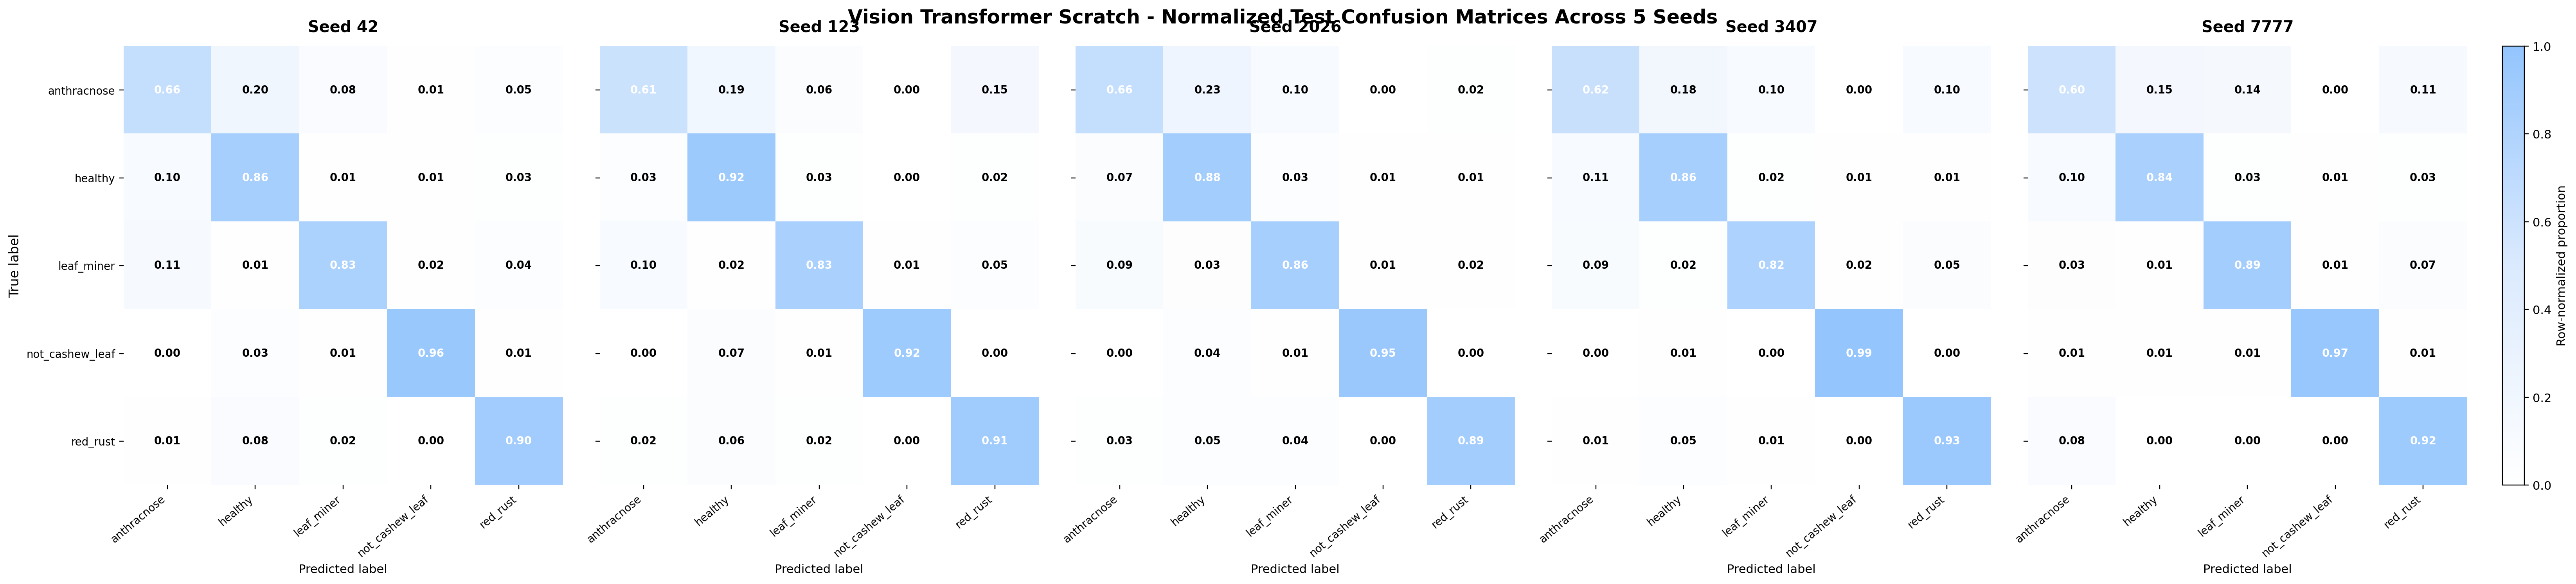

Updated experiment_config.json: final_test_completed = True


In [17]:
# ============================================================
# 17B. PAPER-STYLE TEST CONFUSION MATRIX PANELS
# ============================================================

if not RUN_FINAL_TEST:
    print("Skipped: Final Test chưa chạy.")
else:
    raw_cms = {}
    normalized_cms = {}

    for seed in SEEDS:
        raw_path = OUT_DIR / f"seed_{seed}" / "test_metrics" / "confusion_matrix.csv"
        norm_path = OUT_DIR / f"seed_{seed}" / "test_metrics" / "confusion_matrix_normalized.csv"
        raw_cms[seed] = pd.read_csv(raw_path, index_col=0).to_numpy()
        normalized_cms[seed] = pd.read_csv(norm_path, index_col=0).to_numpy()

    # Raw matrices
    raw_vmax = max(np.max(raw_cms[seed]) for seed in SEEDS)
    fig, axes = plt.subplots(
        1,
        len(SEEDS),
        figsize=(30, 6.5),
        constrained_layout=True
    )

    last_im = None

    for col, seed in enumerate(SEEDS):
        cm = raw_cms[seed]
        ax = axes[col]
        last_im = ax.imshow(
            cm,
            cmap=MATRIX_CMAP,
            vmin=0,
            vmax=raw_vmax,
            aspect="equal"
        )
        ax.set_title(f"Seed {seed}", fontsize=13, fontweight="bold", pad=12)
        ax.set_xticks(range(NUM_CLASSES))
        ax.set_yticks(range(NUM_CLASSES))
        ax.set_xticklabels(CLASS_NAMES, rotation=40, ha="right", fontsize=9)
        if col == 0:
            ax.set_yticklabels(CLASS_NAMES, fontsize=9)
            ax.set_ylabel("True label", fontsize=11)
        else:
            ax.set_yticklabels([])
        ax.set_xlabel("Predicted label", fontsize=10)

        for i in range(NUM_CLASSES):
            for j in range(NUM_CLASSES):
                value = int(cm[i, j])
                color = "white" if value >= raw_vmax * 0.55 else "black"
                ax.text(
                    j,
                    i,
                    f"{value}",
                    ha="center",
                    va="center",
                    fontsize=9,
                    fontweight="bold",
                    color=color
                )

        for spine in ax.spines.values():
            spine.set_visible(False)

    cbar = fig.colorbar(last_im, ax=axes, fraction=0.018, pad=0.015)
    cbar.set_label("Number of images", fontsize=10)
    fig.suptitle(
        "Vision Transformer Scratch - Test Confusion Matrices Across 5 Seeds",
        fontsize=16,
        fontweight="bold"
    )

    raw_panel = PANEL_DIR / "test_confusion_matrices_5seeds_panel.png"
    fig.savefig(raw_panel, dpi=220, bbox_inches="tight")
    plt.close(fig)

    # Normalized matrices
    fig, axes = plt.subplots(
        1,
        len(SEEDS),
        figsize=(30, 6.5),
        constrained_layout=True
    )

    last_im = None

    for col, seed in enumerate(SEEDS):
        cm = normalized_cms[seed]
        ax = axes[col]
        last_im = ax.imshow(
            cm,
            cmap=MATRIX_CMAP,
            vmin=0.0,
            vmax=1.0,
            aspect="equal"
        )
        ax.set_title(f"Seed {seed}", fontsize=13, fontweight="bold", pad=12)
        ax.set_xticks(range(NUM_CLASSES))
        ax.set_yticks(range(NUM_CLASSES))
        ax.set_xticklabels(CLASS_NAMES, rotation=40, ha="right", fontsize=9)
        if col == 0:
            ax.set_yticklabels(CLASS_NAMES, fontsize=9)
            ax.set_ylabel("True label", fontsize=11)
        else:
            ax.set_yticklabels([])
        ax.set_xlabel("Predicted label", fontsize=10)

        for i in range(NUM_CLASSES):
            for j in range(NUM_CLASSES):
                value = float(cm[i, j])
                color = "white" if value >= 0.55 else "black"
                ax.text(
                    j,
                    i,
                    f"{value:.2f}",
                    ha="center",
                    va="center",
                    fontsize=9,
                    fontweight="bold",
                    color=color
                )

        for spine in ax.spines.values():
            spine.set_visible(False)

    cbar = fig.colorbar(last_im, ax=axes, fraction=0.018, pad=0.015)
    cbar.set_label("Row-normalized proportion", fontsize=10)
    fig.suptitle(
        "Vision Transformer Scratch - Normalized Test Confusion Matrices Across 5 Seeds",
        fontsize=16,
        fontweight="bold"
    )

    normalized_panel = PANEL_DIR / "test_confusion_matrices_normalized_5seeds_panel.png"
    fig.savefig(normalized_panel, dpi=220, bbox_inches="tight")
    plt.close(fig)

    print("Created:", raw_panel)
    print("Created:", normalized_panel)
    display(Image.open(normalized_panel))

    # Update metadata only after successful Final Test.
    _cfg = json.loads(config_path.read_text(encoding="utf-8"))
    _cfg.setdefault("test_protocol", {})["run_final_test"] = True
    _cfg["test_protocol"]["final_test_completed"] = True
    config_path.write_text(
        json.dumps(_cfg, indent=2, ensure_ascii=False),
        encoding="utf-8"
    )
    print("Updated experiment_config.json: final_test_completed = True")

# Deployment package for later YOLO integration

Deployment seed được chọn **chỉ bằng Validation**:

```text
highest Validation Macro-F1
→ tie-break: lower Validation Loss
```

Test không tham gia lựa chọn.

Archive sẽ có:

```text
model_package/
├── deployment_model.keras
├── vit_token_feature_extractor.keras
├── vit_embedding_model.keras
├── deployment_metadata.json
└── label_map.json
```

- `deployment_model.keras`: YOLO crop → ViT disease classifier
- `vit_token_feature_extractor.keras`: toàn bộ token features sau Transformer
- `vit_embedding_model.keras`: CLS embedding để feature fusion / downstream model

In [18]:
# ============================================================
# 18. EXPORT DEPLOYMENT MODEL PACKAGE - VALIDATION ONLY
# ============================================================

# ------------------------------------------------------------
# Load validation summary if not already in memory
# ------------------------------------------------------------

if "validation_results_df" not in globals():

    validation_results_df = pd.read_csv(
        AGGREGATE_DIR /
        "validation_results_5seeds.csv"
    )


# ------------------------------------------------------------
# Sanity check columns
# ------------------------------------------------------------

print(
    "Validation columns:"
)

print(
    list(
        validation_results_df.columns
    )
)

required_columns = {
    "seed",
    "val_loss",
    "val_macro_f1",
}

missing_columns = (
    required_columns
    -
    set(
        validation_results_df.columns
    )
)

if missing_columns:

    raise ValueError(
        "Missing validation columns: "
        f"{sorted(missing_columns)}"
    )


# ============================================================
# SELECT DEPLOYMENT SEED USING VALIDATION ONLY
# ============================================================
#
# Rule:
#
# 1. Highest Validation Macro-F1
# 2. If tied -> lower Validation Loss
#
# Test Set is NOT used.
# ============================================================

deployment_rank_df = (
    validation_results_df
    .sort_values(
        by=[
            "val_macro_f1",
            "val_loss",
        ],
        ascending=[
            False,
            True,
        ]
    )
    .reset_index(
        drop=True
    )
)


print(
    "\nDeployment ranking based on Validation:"
)

display(
    deployment_rank_df[
        [
            "seed",
            "val_macro_f1",
            "val_accuracy",
            "val_loss",
        ]
    ]
)


deployment_seed = int(
    deployment_rank_df.loc[
        0,
        "seed"
    ]
)

DEMO_SEED = (
    deployment_seed
)


print(
    "\nSelected deployment seed:",
    deployment_seed
)

print(
    "Selection metric: "
    "highest val_macro_f1"
)

print(
    "Tie-break: "
    "lower val_loss"
)

print(
    "Test used for selection: False"
)


# ============================================================
# CHECKPOINT PATH
# ============================================================

deployment_weights_path = (
    OUT_DIR /
    f"seed_{deployment_seed}" /
    "checkpoints" /
    (
        f"VIT_SCRATCH_"
        f"seed_{deployment_seed}_"
        f"best.weights.h5"
    )
)


if not deployment_weights_path.exists():

    raise FileNotFoundError(
        f"Missing checkpoint: "
        f"{deployment_weights_path}"
    )


print(
    "\nDeployment checkpoint:"
)

print(
    deployment_weights_path
)


# ============================================================
# REBUILD ViT + LOAD BEST WEIGHTS
# ============================================================

tf.keras.backend.clear_session()
gc.collect()


with strategy.scope():

    deployment_model = (
        build_vit_model(
            deployment_seed
        )
    )

    deployment_model.load_weights(
        deployment_weights_path
    )


# ============================================================
# SAVE PORTABLE DEPLOYMENT MODEL
# ============================================================

deployment_model_path = (
    MODEL_PACKAGE_DIR /
    "deployment_model.keras"
)


deployment_model.save(
    deployment_model_path
)


print(
    "\nSaved deployment model:"
)

print(
    deployment_model_path
)


# ============================================================
# TOKEN FEATURE EXTRACTOR
# ============================================================
#
# Output:
# (batch, 197, PROJECTION_DIM)
#
# 196 patch tokens + 1 CLS token
# ============================================================

token_feature_extractor = (
    keras.Model(
        inputs=deployment_model.input,

        outputs=(
            deployment_model
            .get_layer(
                "final_token_features"
            )
            .output
        ),

        name=(
            "ViT_token_feature_extractor"
        )
    )
)


token_feature_path = (
    MODEL_PACKAGE_DIR /
    "vit_token_feature_extractor.keras"
)


token_feature_extractor.save(
    token_feature_path
)


print(
    "Saved token feature extractor:"
)

print(
    token_feature_path
)


# ============================================================
# CLS EMBEDDING MODEL
# ============================================================
#
# Output:
# (batch, PROJECTION_DIM)
#
# Suitable for:
# - YOLO + ViT feature fusion
# - downstream classifier
# - embedding analysis
# ============================================================

embedding_model = (
    keras.Model(
        inputs=deployment_model.input,

        outputs=(
            deployment_model
            .get_layer(
                "cls_embedding"
            )
            .output
        ),

        name="ViT_embedding_model"
    )
)


embedding_model_path = (
    MODEL_PACKAGE_DIR /
    "vit_embedding_model.keras"
)


embedding_model.save(
    embedding_model_path
)


print(
    "Saved ViT embedding model:"
)

print(
    embedding_model_path
)


# ============================================================
# LABEL MAP
# ============================================================

label_map = {
    str(i): class_name
    for i, class_name in enumerate(
        CLASS_NAMES
    )
}


(
    MODEL_PACKAGE_DIR /
    "label_map.json"
).write_text(
    json.dumps(
        label_map,
        indent=2,
        ensure_ascii=False
    ),
    encoding="utf-8"
)


# ============================================================
# DEPLOYMENT METADATA
# ============================================================

deployment_metadata = {

    "experiment_id":
        EXPERIMENT_ID,

    "model":
        MODEL_NAME,

    "training_mode":
        TRAINING_MODE,

    "deployment_seed":
        deployment_seed,

    "selection_source":
        "validation only",

    "selection_metric":
        "val_macro_f1",

    "tie_break":
        "lower val_loss",

    "test_used_for_selection":
        False,

    "validation_macro_f1":
        float(
            deployment_rank_df.loc[
                0,
                "val_macro_f1"
            ]
        ),

    "validation_accuracy":
        float(
            deployment_rank_df.loc[
                0,
                "val_accuracy"
            ]
        ),

    "validation_loss":
        float(
            deployment_rank_df.loc[
                0,
                "val_loss"
            ]
        ),

    "input_size": [
        IMG_SIZE,
        IMG_SIZE,
        3
    ],

    "patch_size":
        PATCH_SIZE,

    "num_patches":
        NUM_PATCHES,

    "sequence_length":
        NUM_PATCHES + 1,

    "projection_dim":
        PROJECTION_DIM,

    "num_heads":
        NUM_HEADS,

    "transformer_layers":
        TRANSFORMER_LAYERS,

    "class_names":
        CLASS_NAMES,

    "contains_rescaling_layer":
        True,

    "external_divide_by_255":
        False,

    "deployment_model":
        "deployment_model.keras",

    "token_feature_extractor":
        "vit_token_feature_extractor.keras",

    "embedding_model":
        "vit_embedding_model.keras",

    "source_weights":
        str(
            deployment_weights_path
        ),
}


(
    MODEL_PACKAGE_DIR /
    "deployment_metadata.json"
).write_text(
    json.dumps(
        deployment_metadata,
        indent=2,
        ensure_ascii=False
    ),
    encoding="utf-8"
)


# ============================================================
# SUMMARY
# ============================================================

print(
    "\n" + "=" * 70
)

print(
    "DEPLOYMENT PACKAGE CREATED"
)

print(
    "=" * 70
)

print(
    f"Seed              : "
    f"{deployment_seed}"
)

print(
    f"Validation F1     : "
    f"{deployment_metadata['validation_macro_f1'] * 100:.2f}%"
)

print(
    f"Validation Acc    : "
    f"{deployment_metadata['validation_accuracy'] * 100:.2f}%"
)

print(
    f"Validation Loss   : "
    f"{deployment_metadata['validation_loss']:.6f}"
)

print(
    "\nArtifacts:"
)

print(
    "- deployment_model.keras"
)

print(
    "- vit_token_feature_extractor.keras"
)

print(
    "- vit_embedding_model.keras"
)

print(
    "- deployment_metadata.json"
)

print(
    "- label_map.json"
)

Validation columns:
['seed', 'val_loss', 'val_accuracy', 'val_macro_precision', 'val_macro_recall', 'val_macro_f1', 'val_balanced_accuracy']

Deployment ranking based on Validation:


,seed,val_macro_f1,val_accuracy,val_loss
0,3407,0.901644,0.905136,0.303734
1,42,0.883481,0.889444,0.321538
2,2026,0.873052,0.878031,0.350799
3,7777,0.870538,0.875892,0.375512
4,123,0.861949,0.868046,0.389828



Selected deployment seed: 3407
Selection metric: highest val_macro_f1
Tie-break: lower val_loss
Test used for selection: False

Deployment checkpoint:
/content/drive/MyDrive/Cashew_Leaf_model_result/training_results/current_dataset/EXP-VIT-SCRATCH-5SEEDS-005/seed_3407/checkpoints/VIT_SCRATCH_seed_3407_best.weights.h5
Global seed set to: 3407

Saved deployment model:
/content/drive/MyDrive/Cashew_Leaf_model_result/training_results/current_dataset/EXP-VIT-SCRATCH-5SEEDS-005/model_package/deployment_model.keras
Saved token feature extractor:
/content/drive/MyDrive/Cashew_Leaf_model_result/training_results/current_dataset/EXP-VIT-SCRATCH-5SEEDS-005/model_package/vit_token_feature_extractor.keras
Saved ViT embedding model:
/content/drive/MyDrive/Cashew_Leaf_model_result/training_results/current_dataset/EXP-VIT-SCRATCH-5SEEDS-005/model_package/vit_embedding_model.keras

DEPLOYMENT PACKAGE CREATED
Seed              : 3407
Validation F1     : 90.16%
Validation Acc    : 90.51%
Validation Loss 

In [19]:
# ============================================================
# 19. EXPORT REUSABLE CODE FOR FUTURE YOLO / CONTINUE TRAINING
# ============================================================

vit_model_builder_code = r"""
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

IMG_SIZE = 224
PATCH_SIZE = 16
NUM_PATCHES = (IMG_SIZE // PATCH_SIZE) ** 2
PROJECTION_DIM = 64
NUM_HEADS = 4
TRANSFORMER_LAYERS = 8
TRANSFORMER_MLP_UNITS = 128
ATTENTION_DROPOUT = 0.10
TRANSFORMER_DROPOUT = 0.10
HEAD_UNITS = 256
HEAD_DROPOUT = 0.40


@tf.keras.utils.register_keras_serializable(package="CashewViT")
class ClassToken(layers.Layer):
    def build(self, input_shape):
        self.cls_token = self.add_weight(
            name="cls_token",
            shape=(1, 1, int(input_shape[-1])),
            initializer=tf.keras.initializers.RandomNormal(stddev=0.02),
            trainable=True,
        )
        super().build(input_shape)

    def call(self, inputs):
        batch_size = tf.shape(inputs)[0]
        cls = tf.tile(self.cls_token, [batch_size, 1, 1])
        return tf.concat([cls, inputs], axis=1)


@tf.keras.utils.register_keras_serializable(package="CashewViT")
class AddPositionEmbedding(layers.Layer):
    def __init__(self, sequence_length, projection_dim, **kwargs):
        super().__init__(**kwargs)
        self.sequence_length = int(sequence_length)
        self.projection_dim = int(projection_dim)

    def build(self, input_shape):
        self.position_embedding = self.add_weight(
            name="position_embedding",
            shape=(1, self.sequence_length, self.projection_dim),
            initializer=tf.keras.initializers.RandomNormal(stddev=0.02),
            trainable=True,
        )
        super().build(input_shape)

    def call(self, inputs):
        return inputs + self.position_embedding

    def get_config(self):
        config = super().get_config()
        config.update({
            "sequence_length": self.sequence_length,
            "projection_dim": self.projection_dim,
        })
        return config


@tf.keras.utils.register_keras_serializable(package="CashewViT")
class ExtractClassToken(layers.Layer):
    def call(self, inputs):
        return inputs[:, 0, :]


def build_data_augmentation(seed):
    return keras.Sequential([
        layers.RandomFlip("horizontal", seed=seed + 1),
        layers.RandomRotation(0.04, seed=seed + 2),
        layers.RandomZoom(
            height_factor=(-0.05, 0.05),
            width_factor=(-0.05, 0.05),
            seed=seed + 3,
        ),
        layers.RandomTranslation(0.03, 0.03, seed=seed + 4),
        layers.RandomContrast(0.08, seed=seed + 5),
    ])


def build_vit_model(seed, num_classes=5):
    keras.utils.set_random_seed(seed)

    inputs = keras.Input((IMG_SIZE, IMG_SIZE, 3), name="image")
    x = build_data_augmentation(seed)(inputs)
    x = layers.Rescaling(1.0 / 255.0, name="rescale_0_1")(x)
    x = layers.Conv2D(
        PROJECTION_DIM,
        PATCH_SIZE,
        strides=PATCH_SIZE,
        padding="valid",
        name="patch_embedding_conv"
    )(x)
    x = layers.Reshape((NUM_PATCHES, PROJECTION_DIM), name="patch_tokens")(x)
    x = ClassToken(name="class_token")(x)
    x = AddPositionEmbedding(
        NUM_PATCHES + 1,
        PROJECTION_DIM,
        name="position_embedding"
    )(x)

    for i in range(TRANSFORMER_LAYERS):
        x1 = layers.LayerNormalization(epsilon=1e-6)(x)
        attn = layers.MultiHeadAttention(
            num_heads=NUM_HEADS,
            key_dim=PROJECTION_DIM // NUM_HEADS,
            dropout=ATTENTION_DROPOUT,
        )(x1, x1)
        attn = layers.Dropout(
            TRANSFORMER_DROPOUT,
            seed=seed + 300 + i
        )(attn)
        x = layers.Add()([x, attn])

        x1 = layers.LayerNormalization(epsilon=1e-6)(x)
        mlp = layers.Dense(TRANSFORMER_MLP_UNITS, activation="gelu")(x1)
        mlp = layers.Dropout(TRANSFORMER_DROPOUT, seed=seed + 100 + i)(mlp)
        mlp = layers.Dense(PROJECTION_DIM)(mlp)
        mlp = layers.Dropout(TRANSFORMER_DROPOUT, seed=seed + 200 + i)(mlp)
        x = layers.Add()([x, mlp])

    tokens = layers.LayerNormalization(
        epsilon=1e-6,
        name="final_token_features"
    )(x)
    cls = ExtractClassToken(name="cls_embedding")(tokens)
    x = layers.Dense(HEAD_UNITS, activation="gelu", name="classifier_dense")(cls)
    x = layers.Dropout(HEAD_DROPOUT, seed=seed + 999, name="classifier_dropout")(x)
    outputs = layers.Dense(num_classes, activation="softmax", name="predictions")(x)

    return keras.Model(inputs, outputs, name=f"ViT_Scratch_seed_{seed}")
"""

(CODE_PACKAGE_DIR / "vit_model_builder.py").write_text(
    vit_model_builder_code,
    encoding="utf-8"
)


yolo_adapter_code = r"""
# YOLO crop -> ViT classifier example.
# deployment_model.keras contains Rescaling(1/255).
# Do NOT divide the crop by 255 outside the model.

from pathlib import Path
import json
import numpy as np
from PIL import Image
from tensorflow import keras
import vit_model_builder  # registers custom layers

MODEL_DIR = Path("model_package")
classifier = keras.models.load_model(
    MODEL_DIR / "deployment_model.keras",
    compile=False,
)
label_map = json.loads((MODEL_DIR / "label_map.json").read_text())


def classify_crop(crop, img_size=224):
    if isinstance(crop, np.ndarray):
        crop = Image.fromarray(crop.astype(np.uint8))

    crop = crop.convert("RGB").resize((img_size, img_size))
    x = np.asarray(crop, dtype=np.float32)[None, ...]
    probs = classifier.predict(x, verbose=0)[0]
    pred_id = int(np.argmax(probs))

    return {
        "class_id": pred_id,
        "class_name": label_map[str(pred_id)],
        "confidence": float(probs[pred_id]),
        "probabilities": probs.tolist(),
    }
"""

(CODE_PACKAGE_DIR / "yolo_vit_classifier_adapter.py").write_text(
    yolo_adapter_code,
    encoding="utf-8"
)


continue_training_code = r"""
from tensorflow import keras
import vit_model_builder  # registers custom layers

model = keras.models.load_model(
    "model_package/deployment_model.keras",
    compile=False,
)

model.compile(
    optimizer=keras.optimizers.AdamW(
        learning_rate=1e-4,
        weight_decay=1e-4,
    ),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"],
)

# Continue with your own train_ds / val_ds:
# model.fit(train_ds, validation_data=val_ds, ...)
"""

(CODE_PACKAGE_DIR / "continue_training_example.py").write_text(
    continue_training_code,
    encoding="utf-8"
)

print("Saved reusable ViT code package.")

Saved reusable ViT code package.


# Manual image inference

Manual prediction dùng `deployment_model.keras`.

Notebook xử lý trường hợp **MirroredStrategy + 2 GPU + 1 ảnh upload** bằng cách repeat cùng một ảnh theo số replicas, tránh lỗi một GPU nhận batch size 0.

Model đã có `Rescaling(1/255)` nên **không chia 255 bên ngoài**.

In [20]:
# ============================================================
# 20. MANUAL UPLOAD IMAGE INFERENCE
#     SAFE FOR MIRRORED STRATEGY
# ============================================================

if "deployment_model" not in globals():
    deployment_model = keras.models.load_model(
        MODEL_PACKAGE_DIR / "deployment_model.keras",
        compile=False
    )


def predict_uploaded_image(model, image_bytes, filename):
    img = Image.open(io.BytesIO(image_bytes)).convert("RGB")
    img_resized = img.resize((IMG_SIZE, IMG_SIZE))
    img_array = np.asarray(img_resized, dtype=np.float32)
    single_batch = np.expand_dims(img_array, axis=0)

    num_replicas = max(1, int(strategy.num_replicas_in_sync))
    inference_batch = np.repeat(
        single_batch,
        repeats=num_replicas,
        axis=0
    )

    all_probs = model.predict(inference_batch, verbose=0)
    probs = all_probs[0]
    pred_idx = int(np.argmax(probs))
    confidence = float(probs[pred_idx])

    result_df = pd.DataFrame({
        "Class": CLASS_NAMES,
        "Probability": probs,
        "Probability (%)": probs * 100,
    }).sort_values("Probability", ascending=False).reset_index(drop=True)

    print("=" * 65)
    print("Image           :", filename)
    print("Prediction      :", CLASS_NAMES[pred_idx])
    print(f"Confidence      : {confidence * 100:.2f}%")
    print("Deployment seed :", DEMO_SEED)
    print("GPU replicas    :", num_replicas)
    print("=" * 65)
    display(result_df)

    plt.figure(figsize=(7, 7))
    plt.imshow(img)
    plt.title(
        f"Prediction: {CLASS_NAMES[pred_idx]}\n"
        f"Confidence: {confidence * 100:.2f}%"
    )
    plt.axis("off")
    plt.tight_layout()
    plt.show()


uploader = widgets.FileUpload(
    accept=".jpg,.jpeg,.png,.webp",
    multiple=False,
    description="Upload Image",
)
predict_button = widgets.Button(
    description="Predict",
    button_style="success",
    icon="check"
)
output = widgets.Output()
display(uploader, predict_button, output)


def get_uploaded_file(upload_widget):
    value = upload_widget.value
    if not value:
        return None, None

    if isinstance(value, (tuple, list)):
        f = value[0]
        content = f["content"]
        if hasattr(content, "tobytes"):
            content = content.tobytes()
        return f["name"], content

    if isinstance(value, dict):
        filename = list(value.keys())[0]
        content = value[filename]["content"]
        if hasattr(content, "tobytes"):
            content = content.tobytes()
        return filename, content

    return None, None


def on_predict_clicked(_):
    with output:
        output.clear_output()
        filename, image_bytes = get_uploaded_file(uploader)

        if image_bytes is None:
            print("Vui lòng upload ảnh trước.")
            return

        try:
            predict_uploaded_image(
                deployment_model,
                image_bytes,
                filename
            )
        except Exception as e:
            print("Prediction error:")
            print(type(e).__name__, ":", e)


predict_button.on_click(on_predict_clicked)
print("Upload một ảnh rồi bấm Predict.")

FileUpload(value={}, accept='.jpg,.jpeg,.png,.webp', description='Upload Image')

Button(button_style='success', description='Predict', icon='check', style=ButtonStyle())

Output()

Upload một ảnh rồi bấm Predict.


## External holdout results — after freezing Validation and internal Test


In [ ]:
# External evaluation is separate from the internal V05 Test driver above.
def make_real_holdout_dataset(holdout_manifest):
    dataset = tf.data.Dataset.from_tensor_slices((
        holdout_manifest["path"].tolist(),
        holdout_manifest["label"].to_numpy(dtype=np.int32),
    ))
    return dataset.map(decode_image, num_parallel_calls=tf.data.AUTOTUNE).batch(
        BATCH_SIZE, drop_remainder=False
    ).prefetch(tf.data.AUTOTUNE)  # No shuffle or augmentation; same input decoding.


def load_real_holdout_model(seed):
    with strategy.scope():
        holdout_model = build_vit_model(seed)
        holdout_model.load_weights(holdout_checkpoints[seed])
    return holdout_model


def clear_real_holdout_session():
    tf.keras.backend.clear_session()
    gc.collect()


if RUN_FINAL_TEST and RUN_REAL_HOLDOUT:
    holdout_checkpoints = {seed: OUT_DIR / f"seed_{seed}" / "checkpoints" / f"VIT_SCRATCH_seed_{seed}_best.weights.h5" for seed in SEEDS}
    real_holdout_results_df = evaluate_real_holdout(
        real_holdout_manifest, real_holdout_audit, CLASS_NAMES, SEEDS, validation_results_df,
        holdout_checkpoints, load_real_holdout_model, make_real_holdout_dataset,
        clear_real_holdout_session, OUT_DIR / "real_holdout", outputs_are_logits=False,
    )
    display(real_holdout_results_df)
else:
    print("External holdout evaluation skipped. Enable RUN_FINAL_TEST after validation is frozen.")


In [21]:
# ============================================================
# 21. ENVIRONMENT + README + ARCHIVE FORMAT
# ============================================================

environment_info = {
    "created_at": datetime.now().isoformat(),
    "python": sys.version,
    "tensorflow": tf.__version__,
    "keras": keras.__version__ if hasattr(keras, "__version__") else "tf.keras",
    "platform": platform.platform(),
    "gpu_count": len(gpus),
    "gpu_devices": [str(g) for g in gpus],
    "strategy": strategy.__class__.__name__,
    "replicas": strategy.num_replicas_in_sync,
}

(ENV_DIR / "environment.json").write_text(
    json.dumps(environment_info, indent=2),
    encoding="utf-8"
)

requirements_text = (
    f"tensorflow=={tf.__version__}\n"
    f"numpy=={np.__version__}\n"
    f"pandas=={pd.__version__}\n"
    "Pillow\n"
    "scikit-learn\n"
    "matplotlib\n"
)

(ENV_DIR / "requirements.txt").write_text(
    requirements_text,
    encoding="utf-8"
)

archive_format = (
    "# KLCN Classification Training Archive Format v1\n\n"
    f"- Experiment: {EXPERIMENT_ID}\n"
    f"- Dataset: {DATASET_VERSION}\n"
    "- Model: Vision Transformer from scratch\n"
    f"- Seeds: {SEEDS}\n"
    f"- Results directory: {RESULTS_ROOT}\n\n"
    "## Required archive content\n"
    "- all five best checkpoints;\n"
    "- deployment model;\n"
    "- ViT token feature extractor;\n"
    "- ViT embedding model;\n"
    "- reusable code for YOLO integration / continued training;\n"
    "- histories, metrics, reports, predictions and error cases;\n"
    "- paper-style 5-seed panels;\n"
    "- environment and requirements;\n"
    "- README, manifest and SHA256 checksums.\n\n"
    "## Figure rule\n"
    "Any figure whose purpose is to compare seeds must present all 5 seeds side-by-side in one panel.\n\n"
    "## Scientific rule\n"
    "Same split + same hyperparameters for all seeds. Test is locked for tuning. "
    "Deployment seed is selected from Validation only.\n"
)

(OUT_DIR / "ARCHIVE_FORMAT.md").write_text(
    archive_format,
    encoding="utf-8"
)

validation_summary_path = AGGREGATE_DIR / "validation_mean_std_summary.csv"
validation_summary = (
    pd.read_csv(validation_summary_path)
    if validation_summary_path.exists()
    else None
)

lines = [
    f"# {EXPERIMENT_ID}", "",
    "**Model:** Vision Transformer (ViT) from scratch  ",
    f"**Dataset:** {DATASET_VERSION}  ",
    f"**Seeds:** `{SEEDS}`", "",
    "## Dataset", "",
    "| Class | Train | Val | Test | Total |",
    "|---|---:|---:|---:|---:|",
]

for cls in CLASS_NAMES:
    r = EXPECTED_COUNTS[cls]
    lines.append(
        f"| {cls} | {r['train']} | {r['val']} | {r['test']} | {r['total']} |"
    )

lines += [
    f"| **TOTAL** | **{EXPECTED_TOTALS['train']}** | "
    f"**{EXPECTED_TOTALS['val']}** | **{EXPECTED_TOTALS['test']}** | "
    f"**{EXPECTED_TOTALS['total']}** |",
    "",
    "## Configuration", "",
    f"- Input: `{IMG_SIZE}×{IMG_SIZE}`",
    f"- Patch size: `{PATCH_SIZE}`",
    f"- Number of patches: `{NUM_PATCHES}`",
    f"- Projection dim: `{PROJECTION_DIM}`",
    f"- Heads: `{NUM_HEADS}`",
    f"- Transformer blocks: `{TRANSFORMER_LAYERS}`",
    f"- Transformer MLP: `{TRANSFORMER_MLP_UNITS}`",
    f"- Batch size: `{BATCH_SIZE}`",
    f"- Initial LR: `{INITIAL_LR}`",
    f"- Weight decay: `{WEIGHT_DECAY}`",
    f"- Max epochs: `{MAX_EPOCHS}`",
    "- Optimizer: AdamW",
    "- Checkpoint: minimum val_loss",
    "",
    "## Training curves — 5 seeds side-by-side", "",
    "![Training curves](./figures/panels/training_curves_5seeds_panel.png)", "",
    "## Validation confusion matrices — 5 seeds side-by-side", "",
    "![Validation CM](./figures/panels/validation_confusion_matrices_5seeds_panel.png)", "",
]

if validation_summary is not None:
    lines += [
        "## Validation Mean ± Std", "",
        "| Metric | Result |",
        "|---|---:|",
    ]
    for _, r in validation_summary.iterrows():
        lines.append(f"| {r['metric']} | **{r['report']}** |")
    lines.append("")

if RUN_FINAL_TEST and (AGGREGATE_DIR / "thesis_test_mean_std_summary.csv").exists():
    thesis = pd.read_csv(AGGREGATE_DIR / "thesis_test_mean_std_summary.csv")
    lines += [
        "## Final Test Mean ± Std", "",
        "| Metric | Result |",
        "|---|---:|",
    ]
    for _, r in thesis.iterrows():
        lines.append(f"| {r['Metric']} | **{r['Report']}** |")
    lines += [
        "",
        "## Test confusion matrices — 5 seeds side-by-side", "",
        "![Test CM](./figures/panels/test_confusion_matrices_5seeds_panel.png)", "",
        "## Normalized Test confusion matrices — 5 seeds side-by-side", "",
        "![Normalized Test CM](./figures/panels/test_confusion_matrices_normalized_5seeds_panel.png)", "",
    ]

if (MODEL_PACKAGE_DIR / "deployment_metadata.json").exists():
    meta = json.loads((MODEL_PACKAGE_DIR / "deployment_metadata.json").read_text())
    lines += [
        "## Deployment / YOLO integration", "",
        f"Deployment seed selected from Validation only: **{meta['deployment_seed']}**.", "",
        "Reusable files:",
        "- `model_package/deployment_model.keras`",
        "- `model_package/vit_token_feature_extractor.keras`",
        "- `model_package/vit_embedding_model.keras`",
        "- `code/vit_model_builder.py`",
        "- `code/yolo_vit_classifier_adapter.py`",
        "- `code/continue_training_example.py`",
        "",
    ]

lines += [
    "## Google Drive archive", "",
    f"Full ZIP destination: {RESULTS_ROOT}", "",
    f"Archive name: `{EXPERIMENT_ID}_FULL.zip`", "",
    "## Scientific rules", "",
    "- Same Train/Val/Test split for all seeds.",
    "- Same hyperparameters for all seeds.",
    "- Test is not used for tuning.",
    "- Deployment seed is selected from Validation only.",
    "- Mean ± sample standard deviation (`ddof=1`).",
]

(OUT_DIR / "README.md").write_text(
    "\n".join(lines),
    encoding="utf-8"
)

print("Saved README and environment metadata.")

Saved README and environment metadata.


In [22]:

# ============================================================
# 22. MANIFEST + SHA256 + FULL/ANALYSIS ZIP
# ============================================================

# ------------------------------------------------------------
# File manifest + checksums
# ------------------------------------------------------------
manifest_rows = []
checksum_lines = []

for file_path in sorted(OUT_DIR.rglob("*")):
    if not file_path.is_file():
        continue
    relative = file_path.relative_to(OUT_DIR)
    if relative.name in {"FILE_MANIFEST.csv", "CHECKSUMS.sha256"}:
        continue

    sha = hashlib.sha256()
    with file_path.open("rb") as f:
        while True:
            chunk = f.read(1024 * 1024)
            if not chunk:
                break
            sha.update(chunk)
    digest = sha.hexdigest()
    manifest_rows.append({
        "path": str(relative),
        "size_bytes": int(file_path.stat().st_size),
        "size_mb": float(file_path.stat().st_size / (1024 ** 2)),
        "sha256": digest,
    })
    checksum_lines.append(f"{digest}  {relative}")

pd.DataFrame(manifest_rows).to_csv(OUT_DIR / "FILE_MANIFEST.csv", index=False)
(OUT_DIR / "CHECKSUMS.sha256").write_text("\n".join(checksum_lines), encoding="utf-8")

# ------------------------------------------------------------
# Full archive: contains models/checkpoints for future reuse.
# Dataset images are NOT copied into the archive.
# ------------------------------------------------------------
FULL_ZIP = RESULTS_ROOT / f"{EXPERIMENT_ID}_FULL.zip"
ANALYSIS_ZIP = RESULTS_ROOT / f"{EXPERIMENT_ID}_ANALYSIS.zip"

with zipfile.ZipFile(FULL_ZIP, "w", compression=zipfile.ZIP_DEFLATED) as zipf:
    for file_path in OUT_DIR.rglob("*"):
        if file_path.is_file():
            relative = file_path.relative_to(OUT_DIR)
            zipf.write(file_path, arcname=Path(EXPERIMENT_ID) / relative)

# Lightweight archive for ChatGPT / analysis.
allowed = {".csv", ".json", ".md", ".png", ".txt", ".sha256"}
skip_folders = {"checkpoints", "model_package"}

with zipfile.ZipFile(ANALYSIS_ZIP, "w", compression=zipfile.ZIP_DEFLATED) as zipf:
    for file_path in OUT_DIR.rglob("*"):
        if not file_path.is_file():
            continue
        relative = file_path.relative_to(OUT_DIR)
        if any(part in skip_folders for part in relative.parts):
            continue
        if file_path.suffix.lower() not in allowed:
            continue
        zipf.write(file_path, arcname=Path(EXPERIMENT_ID) / relative)

print("=" * 70)
print("ARCHIVES READY")
print("=" * 70)
print("FULL ZIP     :", FULL_ZIP)
print(f"FULL SIZE    : {FULL_ZIP.stat().st_size / (1024 ** 2):.2f} MB")
print("ANALYSIS ZIP :", ANALYSIS_ZIP)
print(f"ANALYSIS SIZE: {ANALYSIS_ZIP.stat().st_size / (1024 ** 2):.2f} MB")
print()
print("RESULTS DIRECTORY:", RESULTS_ROOT)


ARCHIVES READY
FULL ZIP     : /content/drive/MyDrive/Cashew_Leaf_model_result/training_results/current_dataset/EXP-VIT-SCRATCH-5SEEDS-005_FULL.zip
FULL SIZE    : 25.65 MB
ANALYSIS ZIP : /content/drive/MyDrive/Cashew_Leaf_model_result/training_results/current_dataset/EXP-VIT-SCRATCH-5SEEDS-005_ANALYSIS.zip
ANALYSIS SIZE: 3.38 MB

RESULTS DIRECTORY: /content/drive/MyDrive/Cashew_Leaf_model_result/training_results/current_dataset


# Final checklist — common project format

## Dataset
- [ ] 6,911 valid images
- [ ] 0 invalid images
- [ ] same fixed split as ResNet50 / DenseNet121

## Training
- [ ] Seed 42
- [ ] Seed 123
- [ ] Seed 2026
- [ ] Seed 3407
- [ ] Seed 7777
- [ ] best checkpoint for every seed
- [ ] Validation Mean ± Std

## Paper-style figures
- [ ] `training_curves_5seeds_panel.png`
- [ ] `validation_confusion_matrices_5seeds_panel.png`
- [ ] `test_confusion_matrices_5seeds_panel.png`
- [ ] `test_confusion_matrices_normalized_5seeds_panel.png`

## Final Test
- [ ] only after config lock
- [ ] per-seed metrics
- [ ] Mean ± Std
- [ ] per-class Mean ± Std
- [ ] predictions / error cases

## Reuse / YOLO
- [ ] all 5 best weights
- [ ] `deployment_model.keras`
- [ ] `vit_token_feature_extractor.keras`
- [ ] `vit_embedding_model.keras`
- [ ] `vit_model_builder.py`
- [ ] YOLO adapter
- [ ] continue-training example

## Archive
- [ ] FULL ZIP
- [ ] ANALYSIS ZIP
- [ ] manifest
- [ ] SHA256 checksums
- [ ] FULL ZIP archived to project Google Drive folder